# Predicting Customer Churn: A Data-Driven Analysis of Subscription Customer Behaviour

## Capstone Project – India Data Research Academy (IDRA)

**Project Type:** Machine Learning – Classification

**Domain:** Customer Relationship Management / Telecommunications

**Target Variable:** Churn


## 1. Project Overview

Customer churn refers to the situation in which a customer stops using a company's products or services. 
For subscription-based businesses, understanding and predicting customer churn is important because 
retaining existing customers can be more effective than continuously acquiring new ones.

This project focuses on analysing customer subscription behaviour and identifying the factors associated 
with customer churn. Exploratory Data Analysis (EDA), statistical analysis, data preprocessing, and 
machine learning classification techniques will be used to understand customer behaviour and predict 
whether a customer is likely to churn.

The analysis will also identify important factors associated with churn and translate the findings into 
meaningful business insights and recommendations.

## 2. Problem Statement

Customer churn can negatively affect the revenue and long-term growth of subscription-based businesses.

The objective of this project is to analyse customer data and identify the factors that are associated 
with customer churn. Based on these factors, machine learning classification models will be developed 
to predict whether a customer is likely to churn.

The analysis will also provide actionable insights that can help businesses identify high-risk customers 
and develop appropriate customer retention strategies.

## 3. Project Objectives

The major objectives of this project are:

1. To understand the structure and characteristics of the customer churn dataset.
2. To perform exploratory data analysis (EDA) on customer demographics, services, contracts, and billing information.
3. To identify missing values, duplicate records, inconsistent data types, and potential outliers.
4. To analyse the relationship between customer characteristics and churn.
5. To identify important factors associated with customer churn.
6. To preprocess and transform the dataset for machine learning.
7. To develop multiple classification models for predicting customer churn.
8. To evaluate and compare the performance of the classification models.
9. To identify the most influential features contributing to churn prediction.
10. To provide data-driven recommendations for reducing customer churn.

## 4. Research Questions

The analysis will attempt to answer the following questions:

1. What proportion of customers have churned?
2. Which customer characteristics are associated with higher churn?
3. Does customer tenure have a relationship with churn?
4. Does contract type influence customer churn?
5. How does internet service type relate to churn?
6. Does the payment method affect customer churn?
7. How are monthly charges related to customer churn?
8. Which services or service combinations are associated with lower or higher churn?
9. Which customer features are the strongest predictors of churn?
10. Which machine learning classification model provides the best predictive performance?
11. How can the findings be used to improve customer retention strategies?

In [1]:
# Import required libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set plotting style
sns.set_theme(style='whitegrid')

print("Libraries imported successfully.")

Libraries imported successfully.


## 5. Loading the Dataset

The dataset provided for this project contains customer-level information from a telecommunications 
service provider. It includes demographic characteristics, service subscriptions, contract details, 
billing information, and the customer's churn status.

The dataset will be loaded into a Pandas DataFrame for further analysis.

In [2]:
# Load the dataset
import pandas as pd
file_path = "P_4_WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(file_path)
print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (7043, 21)


## 6. Initial Dataset Inspection

Before performing any analysis, the dataset will be inspected to understand its dimensions, 
variables, data types, and initial observations.

In [3]:
# Display the first five rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Display the last five rows
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [5]:
# Check the number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 7043
Number of columns: 21


### 6.1 Dataset Dimensions

The shape of the dataset is examined to determine the number of observations and variables available 
for analysis.

In [6]:
# Dataset dimensions
rows, columns = df.shape
print(f"Rows: {rows}")
print(f"Columns: {columns}")

Rows: 7043
Columns: 21


### 6.2 Dataset Variables

The names of all variables in the dataset are examined to understand the information available for 
customer-level analysis.

In [7]:
# Display all column names
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

1. customerID
2. gender
3. SeniorCitizen
4. Partner
5. Dependents
6. tenure
7. PhoneService
8. MultipleLines
9. InternetService
10. OnlineSecurity
11. OnlineBackup
12. DeviceProtection
13. TechSupport
14. StreamingTV
15. StreamingMovies
16. Contract
17. PaperlessBilling
18. PaymentMethod
19. MonthlyCharges
20. TotalCharges
21. Churn


### 6.3 Data Types

The data types of all variables are examined to determine which variables are numerical and which are 
categorical. This is important for selecting appropriate analysis and preprocessing techniques.

In [8]:
# Display data types
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [9]:
# Summary of data types
df.dtypes.value_counts()

str        18
int64       2
float64     1
Name: count, dtype: int64

### 6.4 Dataset Information

The DataFrame information is examined to understand the data types, number of non-null observations, 
and memory usage of the dataset.

In [10]:
# Display dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### 6.5 Descriptive Statistics

Descriptive statistics are used to summarize the numerical variables in the dataset. 
Measures such as count, mean, standard deviation, minimum, maximum, and quartiles 
will be examined.

In [11]:
# Descriptive statistics for numerical variables
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
# Descriptive statistics for all variables

df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 6.6 Numerical and Categorical Variables

The variables are divided into numerical and categorical groups. This classification will be useful 
during exploratory data analysis and later during machine learning preprocessing.

In [13]:
# Identify numerical variables
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
print("Numerical Variables:")
print(numerical_columns)

Numerical Variables:
['SeniorCitizen', 'tenure', 'MonthlyCharges']


In [14]:
# Identify categorical variables
categorical_columns = df.select_dtypes(include='object').columns.tolist()
print("Categorical Variables:")
print(categorical_columns)

Categorical Variables:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


### 6.7 Unique Values in Variables

The number of unique values in each variable is examined to understand the structure and diversity 
of the dataset and to identify categorical variables with a small number of categories.

In [15]:
# Display unique values for categorical variables
for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


customerID:
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

gender:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines:
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService:
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity:
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup:
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection:
<StringArray>
['No', 'Yes', 'No internet 

## 7. Data Quality Assessment

Before performing exploratory data analysis, the dataset will be assessed for data-quality issues.

The assessment will include:

- Missing and blank values
- Duplicate records
- Duplicate customer IDs
- Incorrect data types
- Inconsistent categorical values
- Numerical variables requiring conversion
- Potential outliers

This step is important because data-quality issues can affect the accuracy and reliability of subsequent statistical analysis and machine learning models.

### 7.1 Missing Value Assessment

Missing values are examined across all variables to determine whether any observations require treatment before analysis.

In [16]:
# Check missing values
missing_values = df.isnull().sum()
missing_values

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [17]:
# Display only columns containing missing values
missing_values[missing_values > 0]

Series([], dtype: int64)

### 7.2 Blank and Empty Values

Some datasets may contain blank strings instead of formally recognized missing values. Therefore, object-type variables are checked for empty or whitespace-only entries.

In [18]:
# Check blank or whitespace-only values in categorical/string columns
blank_counts = {}
for column in df.select_dtypes(include='object').columns:
    blank_counts[column] = df[column].astype(str).str.strip().eq('').sum()
blank_counts = pd.Series(blank_counts).sort_values(ascending=False)
blank_counts

TotalCharges        11
customerID           0
gender               0
Partner              0
PhoneService         0
Dependents           0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
MultipleLines        0
DeviceProtection     0
TechSupport          0
StreamingMovies      0
StreamingTV          0
Contract             0
PaperlessBilling     0
PaymentMethod        0
Churn                0
dtype: int64

In [19]:
# Inspect blank TotalCharges records
df[df['TotalCharges'].astype(str).str.strip() == '']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


### 7.3 Duplicate Record Assessment
Duplicate records are checked to determine whether the dataset contains repeated customer observations.

In [20]:
# Check for completely duplicated rows
duplicate_rows = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


### 7.4 Duplicate Customer ID Assessment
The customer ID should uniquely identify each customer. Duplicate customer IDs are therefore examined separately.

In [21]:
# Check duplicate customer IDs
duplicate_customer_ids = df['customerID'].duplicated().sum()
print("Number of duplicate customer IDs:", duplicate_customer_ids)

Number of duplicate customer IDs: 0


### 7.5 Categorical Value Consistency
The unique values of categorical variables are examined to identify unexpected spellings, inconsistent labels, or unusual categories.

In [22]:
# Display value counts for all categorical variables
for column in categorical_columns:
    print(f"\n{'='*50}")
    print(f"{column}")
    print(f"{'='*50}")
    print(df[column].value_counts(dropna=False))


customerID
customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
             ..
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No                     3088
Yes                    2429


### 7.6 Investigation of TotalCharges
The `TotalCharges` variable represents the total amount charged to a customer. However, it is currently stored as a string variable.
A temporary numeric version will be created to identify values that cannot be converted to numbers.

In [23]:
# Temporarily convert TotalCharges to numeric
totalcharges_numeric = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Count values that could not be converted
print("Non-numeric/blank TotalCharges values:", totalcharges_numeric.isna().sum())

Non-numeric/blank TotalCharges values: 11


In [24]:
# Display records where TotalCharges could not be converted
df[totalcharges_numeric.isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [25]:
# Compare tenure for these records
df.loc[totalcharges_numeric.isna(), ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


### 7.7 Numerical Variable Range Check
The minimum and maximum values of numerical variables are examined to identify potentially unusual or impossible values.

In [26]:
# Numerical variable range check
for column in numerical_columns:
    print(f"\n{column}")
    print("Minimum:", df[column].min())
    print("Maximum:", df[column].max())


SeniorCitizen
Minimum: 0
Maximum: 1

tenure
Minimum: 0
Maximum: 72

MonthlyCharges
Minimum: 18.25
Maximum: 118.75


## 8. Data Cleaning and Preparation

Based on the data-quality assessment, the dataset contains 7,043 customer records with no duplicate rows or duplicate customer IDs.

The main data-quality issue identified is that the `TotalCharges` variable is stored as a string and contains 11 blank values. These blank values occur for customers with zero months of tenure.

The following cleaning procedures will therefore be performed:

1. Convert `TotalCharges` from string to numeric format.
2. Treat blank `TotalCharges` values for zero-tenure customers as 0.
3. Remove `customerID` from analytical features because it is a unique identifier and does not provide predictive information.
4. Preserve meaningful categories such as `No internet service` and `No phone service`.
5. Verify the cleaned dataset after transformation.

### 8.1 Converting TotalCharges to Numeric

The `TotalCharges` variable represents the cumulative amount charged to each customer. Since it is currently stored as a string, it must be converted to a numerical data type before statistical analysis and machine learning.

Blank entries will initially be converted to missing numerical values so that they can be handled appropriately.

In [27]:
# Convert TotalCharges from string to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check the resulting data type
print("TotalCharges data type:", df['TotalCharges'].dtype)

# Count missing values after conversion
print("Missing TotalCharges values:", df['TotalCharges'].isna().sum())

TotalCharges data type: float64
Missing TotalCharges values: 11


### 8.2 Handling Missing TotalCharges Values

The 11 records with missing `TotalCharges` values are examined alongside their tenure and monthly charges.

Since all identified records have zero tenure, their cumulative charges can reasonably be represented as zero for this analysis.

In [28]:
# Verify tenure of records with missing TotalCharges
df.loc[df['TotalCharges'].isna(), ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [29]:
# Check whether all missing TotalCharges records have zero tenure
print(
    "All missing TotalCharges records have zero tenure:",
    (df.loc[df['TotalCharges'].isna(), 'tenure'] == 0).all()
)

All missing TotalCharges records have zero tenure: True


In [30]:
# Replace missing TotalCharges values with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print("Missing TotalCharges after treatment:", df['TotalCharges'].isna().sum())

Missing TotalCharges after treatment: 0


### 8.3 Verification of Numerical Variables

After converting `TotalCharges`, the numerical variables are rechecked to ensure that their data types and ranges are appropriate for further analysis.

In [31]:
# Display numerical data types
df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']].dtypes

SeniorCitizen       int64
tenure              int64
MonthlyCharges    float64
TotalCharges      float64
dtype: object

In [32]:
# Descriptive statistics after cleaning
df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


### 8.4 Handling the Customer ID
The `customerID` variable is a unique identifier assigned to each customer. Because every customer has a unique ID, it does not contain meaningful behavioural information for churn analysis.
Therefore, `customerID` will be excluded from the analytical feature set while the original dataset is retained for reference.

In [33]:
# Create a copy for analysis
df_analysis = df.copy()

# Remove customerID from analytical features
df_analysis = df_analysis.drop(columns=['customerID'])

print("Original dataset shape:", df.shape)
print("Analytical dataset shape:", df_analysis.shape)

Original dataset shape: (7043, 21)
Analytical dataset shape: (7043, 20)


### 8.5 Final Missing-Value Check

A final missing-value check is performed after the cleaning procedures to confirm that the analytical dataset is ready for exploratory analysis.

In [34]:
# Final missing-value check
final_missing = df_analysis.isna().sum()

print("Total missing values in analytical dataset:", final_missing.sum())

final_missing[final_missing > 0]

Total missing values in analytical dataset: 0


Series([], dtype: int64)

### 8.6 Final Duplicate Check

The analytical dataset is checked again for duplicate records after the cleaning process.

In [35]:
# Final duplicate check
print("Duplicate rows:", df_analysis.duplicated().sum())

Duplicate rows: 22


### 8.7 Final Dataset Verification

The cleaned dataset is inspected to confirm its dimensions, data types, and overall structure before beginning exploratory data analysis.

In [36]:
# Final dataset information
df_analysis.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [37]:
# Display the first five rows of the cleaned analytical dataset
df_analysis.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 8.8 Investigation of Duplicate Analytical Records

After excluding `customerID`, 22 duplicate analytical records were identified.

These records may represent different customers who happen to have identical demographic, service, contract, billing, and churn characteristics. Therefore, they will be investigated before deciding whether they should be removed.

Duplicate analytical records will not be automatically treated as erroneous observations.

In [38]:
# Count duplicate records in the analytical dataset
print("Number of duplicate analytical rows:", df_analysis.duplicated().sum())

Number of duplicate analytical rows: 22


In [39]:
# Display duplicate analytical records
duplicate_analytical_records = df_analysis[
    df_analysis.duplicated(keep=False)
].sort_values(by=df_analysis.columns.tolist())

duplicate_analytical_records

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6491,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.20,69.20,Yes
6764,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.20,69.20,Yes
4495,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.10,70.10,Yes
6267,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.10,70.10,Yes
5522,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15,Yes
5759,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15,Yes
542,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
1491,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
5170,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65,No
6774,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65,No


### 8.9 Verification of Customer IDs for Duplicate Analytical Records

The customer IDs corresponding to duplicate analytical records are examined to determine whether the records belong to different customers.

If the customer IDs are different, the observations will be considered valid customer records rather than duplicate customers.

In [40]:
# Retrieve original customer IDs for the duplicate analytical records
duplicate_indices = df_analysis[
    df_analysis.duplicated(keep=False)
].index

df.loc[duplicate_indices].sort_values(
    by=df_analysis.columns.tolist()
)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6491,9728-FTTVZ,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.20,69.20,Yes
6764,7660-HDPJV,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.20,69.20,Yes
4495,4702-IOQDC,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.10,70.10,Yes
6267,0328-GRPMV,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.10,70.10,Yes
5522,2619-WFQWU,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15,Yes
5759,9985-MWVIX,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15,Yes
542,2866-IKBTM,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
1491,8605-ITULD,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
5170,7721-DVEKZ,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65,No
6774,0970-QXPXW,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65,No


In [41]:
df.loc[duplicate_indices].sort_values('customerID')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6267,0328-GRPMV,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.10,70.10,Yes
3499,0426-TIRNE,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.90,20.90,Yes
2121,0673-IGUQO,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.45,20.45,No
646,0887-HJGAR,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,45.70,45.70,Yes
6774,0970-QXPXW,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65,No
6609,1000-AJSLD,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.10,20.10,Yes
22,1066-JKSGK,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes
3679,1240-KNSEZ,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.10,20.10,Yes
1338,1934-SJVJK,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes
6518,1963-SVUCV,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,45.30,45.30,Yes


### 8.10 Duplicate Record Decision

Duplicate observations are considered true duplicates only when they represent the same customer or an erroneous repeated observation.

If duplicate analytical records have different customer IDs, they represent different customers with identical observed characteristics and should therefore be retained.

In [42]:
# Check whether the duplicate analytical records have unique customer IDs
unique_ids_among_duplicates = df.loc[duplicate_indices, 'customerID'].nunique()

total_duplicate_records = len(duplicate_indices)

print("Duplicate analytical records:", total_duplicate_records)
print("Unique customer IDs among them:", unique_ids_among_duplicates)

Duplicate analytical records: 42
Unique customer IDs among them: 42


### 8.11 Duplicate Record Treatment

The 42 duplicate analytical records were found to correspond to different customer IDs. Therefore, these records represent different customers with identical values across the analytical variables rather than duplicate customer observations.

Consequently, the records were retained in the dataset.

In [43]:
# Verify the final analytical dataset
print("Final number of rows:", df_analysis.shape[0])
print("Final number of columns:", df_analysis.shape[1])
print("Duplicate customer IDs:", df['customerID'].duplicated().sum())

Final number of rows: 7043
Final number of columns: 20
Duplicate customer IDs: 0


In [44]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

### Handling Duplicate Analytical Records

After removing the unique `customerID` column, 42 analytical duplicate records were identified. However, these records correspond to 42 unique customer IDs in the original dataset. Therefore, they represent different customers with identical values across the analytical variables rather than duplicate customer records.

Since each customer has a unique customer ID, these records were retained to preserve the complete customer population and avoid unnecessary loss of observations.

In [45]:
# Detect outliers using the IQR method

numerical_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numerical_columns:
    Q1 = df_analysis[col].quantile(0.25)
    Q3 = df_analysis[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_analysis[
        (df_analysis[col] < lower_bound) |
        (df_analysis[col] > upper_bound)
    ]
    
    print(f"\n{col}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")
    print(f"Number of Outliers: {len(outliers)}")


tenure
Q1: 9.0
Q3: 55.0
IQR: 46.0
Lower Bound: -60.0
Upper Bound: 124.0
Number of Outliers: 0

MonthlyCharges
Q1: 35.5
Q3: 89.85
IQR: 54.349999999999994
Lower Bound: -46.02499999999999
Upper Bound: 171.375
Number of Outliers: 0

TotalCharges
Q1: 398.55
Q3: 3786.6
IQR: 3388.0499999999997
Lower Bound: -4683.525
Upper Bound: 8868.675
Number of Outliers: 0


### Outlier Detection

Outliers were examined in the numerical variables `tenure`, `MonthlyCharges`, and `TotalCharges` using the Interquartile Range (IQR) method.

No outliers were detected in any of the three variables. Therefore, no observations were removed on the basis of outlier detection, and the dataset was retained in its complete form.

In [46]:
# Final data cleaning verification

print("Final Dataset Shape:", df_analysis.shape)
print("\nMissing Values:")
print(df_analysis.isnull().sum())

print("\nDuplicate Rows:", df_analysis.duplicated().sum())
print("Duplicate Customer IDs:", df['customerID'].duplicated().sum())

print("\nData Types:")
print(df_analysis.dtypes)

Final Dataset Shape: (7043, 20)

Missing Values:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate Rows: 22
Duplicate Customer IDs: 0

Data Types:
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling   

##  Data Cleaning — Summary

The dataset was cleaned and prepared for analysis through several steps. The `TotalCharges` column was converted from string to numeric format, and 11 blank values were replaced with 0 after confirming that the corresponding customers had a tenure of 0 months. The unique `customerID` column was excluded from the analytical dataset but retained in the original dataset for reference.

No missing values remained after cleaning. Duplicate customer IDs were not found. Although 42 analytical records were identified as belonging to duplicate groups after removing `customerID`, these records represented different customers with unique customer IDs and were therefore retained.

Outlier detection using the IQR method found no outliers in `tenure`, `MonthlyCharges`, or `TotalCharges`.

The final analytical dataset contains 7,043 customer records and 20 variables with no missing values.

#  9.  Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the structure, distribution, and important patterns present in the Telco Customer Churn dataset.

The analysis focuses on both **univariate and bivariate analysis** to identify trends and relationships between customer characteristics, services, charges, tenure, and churn.

### Objectives of EDA

- Understand the distribution of individual variables.
- Analyze customer demographics and service usage.
- Examine the relationship between different variables and customer churn.
- Identify patterns that may influence customer retention.
- Generate meaningful insights that can be used for further analysis and modeling.

## 9.1 Churn Distribution

The target variable `Churn` is analyzed to understand the proportion of customers who have discontinued the service compared with those who have remained with the company.

Both the frequency and percentage distribution of churn will be examined to determine whether the target variable is balanced or imbalanced.

In [47]:
# Churn distribution

churn_counts = df_analysis['Churn'].value_counts()

print("Churn Counts:")
print(churn_counts)

print("\nChurn Percentage:")
print(df_analysis['Churn'].value_counts(normalize=True) * 100)

Churn Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


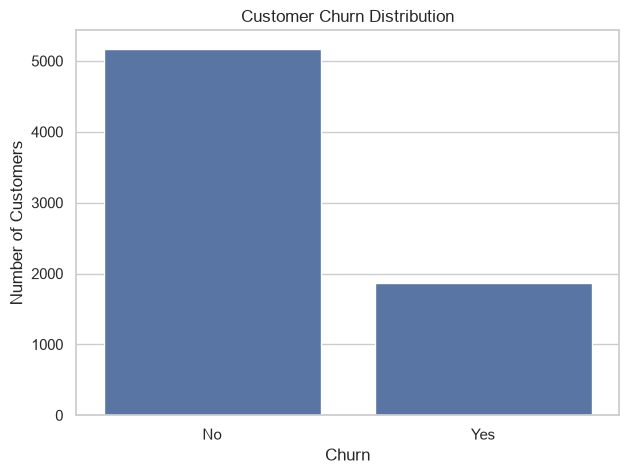

In [48]:
# Visualize churn distribution

plt.figure(figsize=(7, 5))

sns.countplot(data=df_analysis, x='Churn')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

### 9.1.1 Observations

- The dataset contains a higher number of customers who **did not churn** compared to customers who **churned**.

- This indicates that the majority of customers have continued their services, while a smaller proportion have discontinued them.

- The difference between the two categories shows that the **Churn variable is imbalanced**, with the non-churned class being dominant.

- This class imbalance should be considered during the later **predictive modeling and evaluation** stages.

## 9.2 Numerical Variable Distribution Analysis— Univariate Analysis

The distribution of the numerical variables `tenure`, `MonthlyCharges`, and `TotalCharges` is examined to understand their central tendency, spread, and overall distribution among customers.

Histograms with density curves are used to visually assess the distribution of each variable and identify patterns such as skewness or concentration of observations.

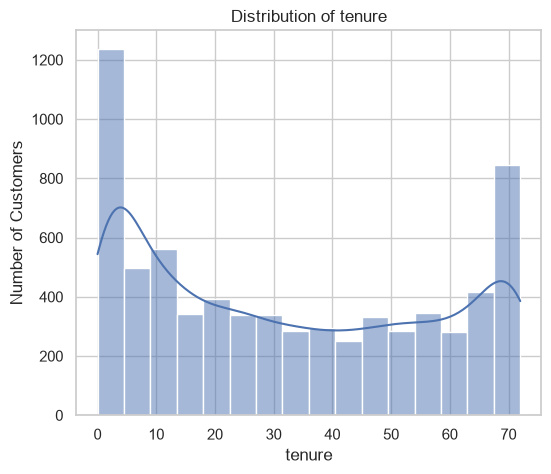

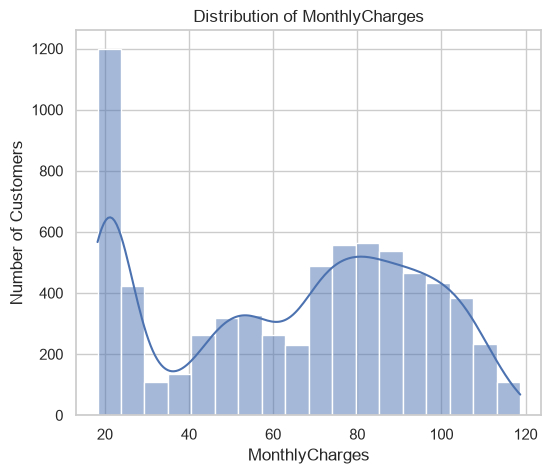

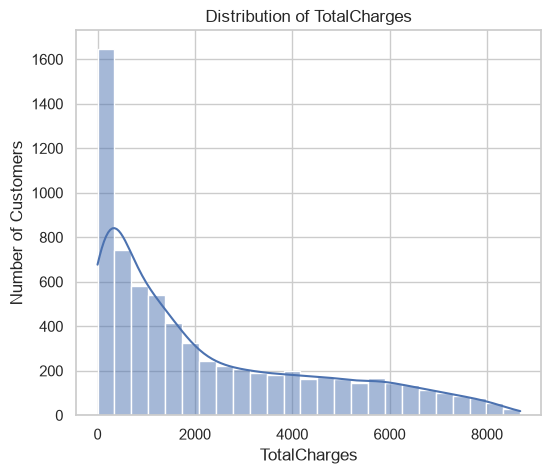

In [49]:
# Distribution of numerical variables

numerical_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numerical_columns:
    plt.figure(figsize=(6, 5))
    
    sns.histplot(data=df_analysis, x=col, kde=True)
    
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Number of Customers')
    
    plt.show()

### 9.2.1 Observations

- **Tenure:** Customers are concentrated at lower tenure values, with another noticeable concentration around 60–72 months. This suggests that both newer and long-term customers are well represented in the dataset.

- **Monthly Charges:** Monthly charges are distributed across a broad range, with a substantial concentration around ₹70–₹100. A smaller group of customers has relatively low monthly charges.

- **Total Charges:** Total charges show a strong right-skewed distribution. Many customers have relatively low total charges, while fewer long-tenure customers accumulate substantially higher total charges.

- **Overall Observation:** The numerical variables show noticeable differences in their distributions, providing useful insights into customer tenure and billing patterns.

## 9.3 Categorical Variable Distribution Analysis— Univariate Analysis
The categorical variables are analyzed to understand the composition of the customer base across different demographic, service-related, contract, billing, and payment characteristics.
Count plots are used to examine the frequency of each category and identify dominant customer segments within the dataset.

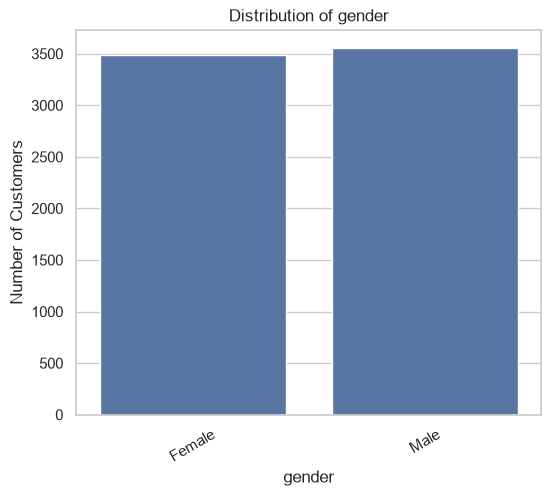

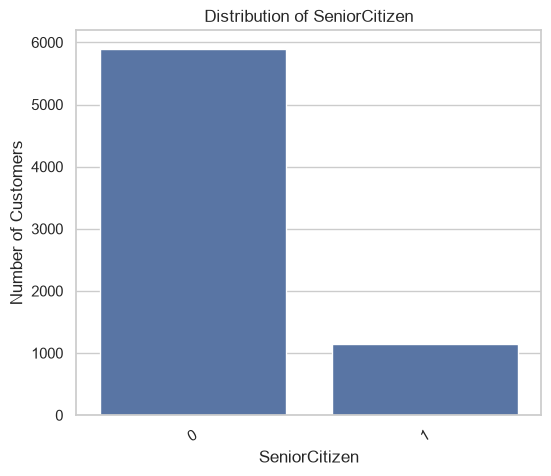

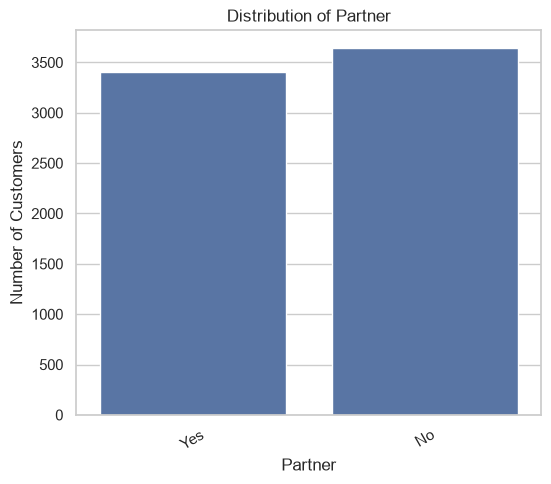

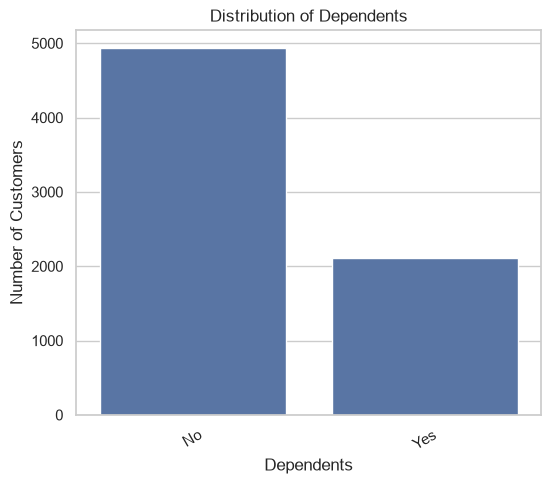

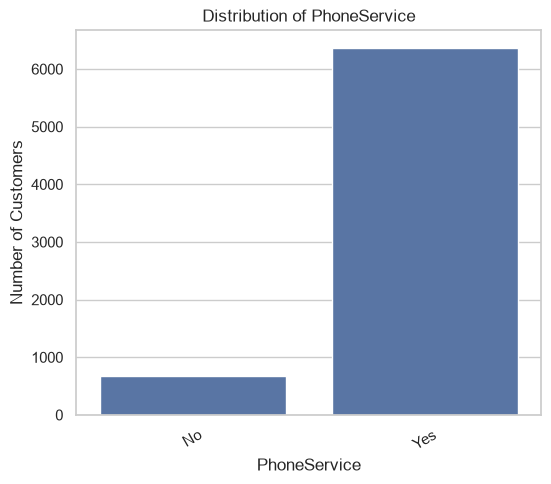

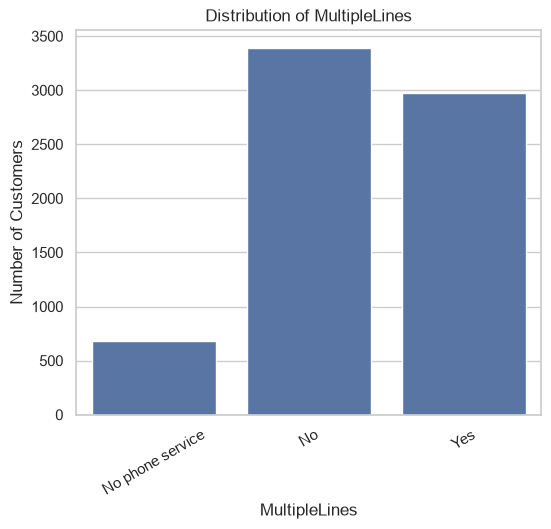

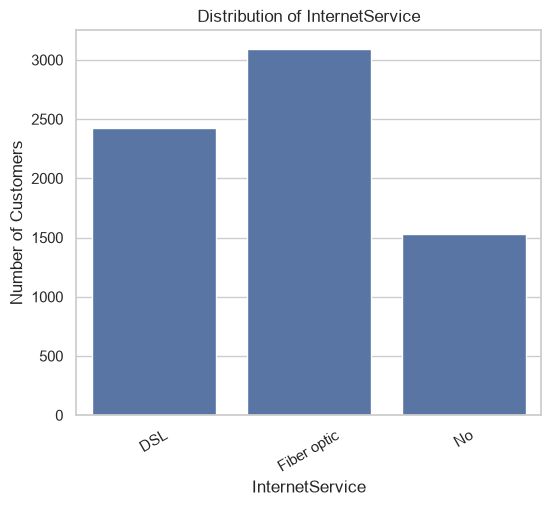

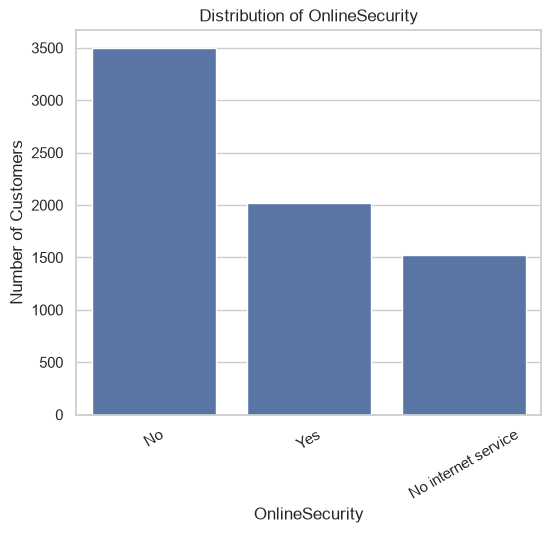

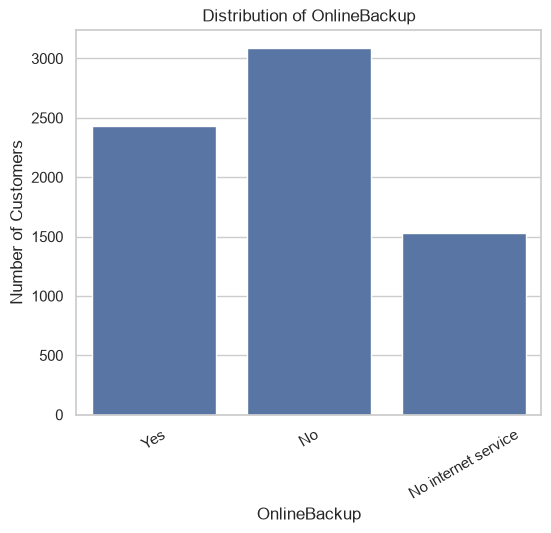

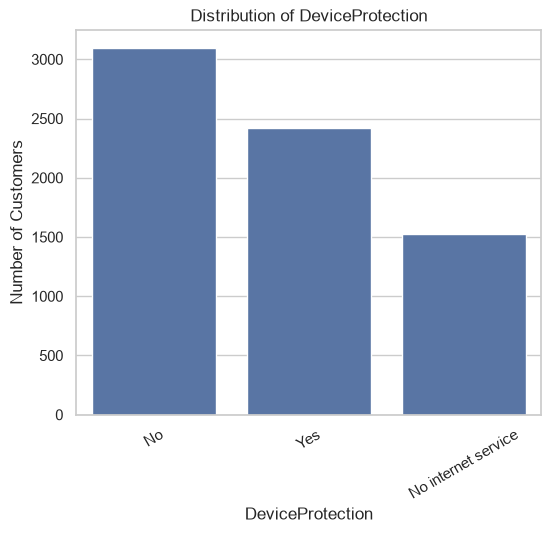

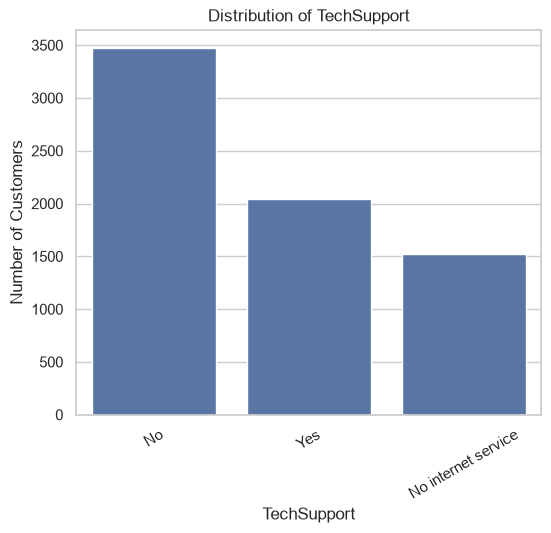

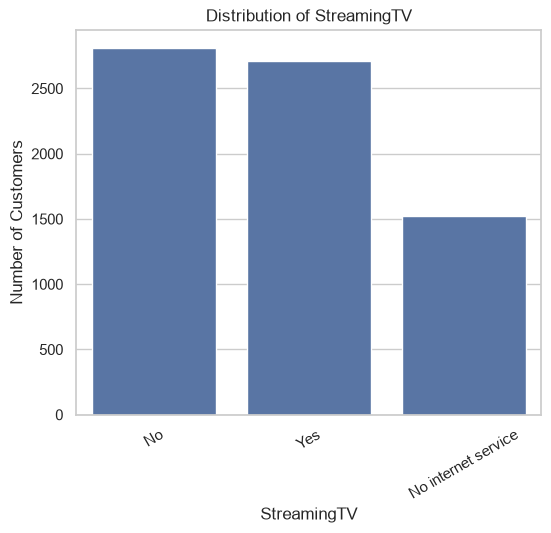

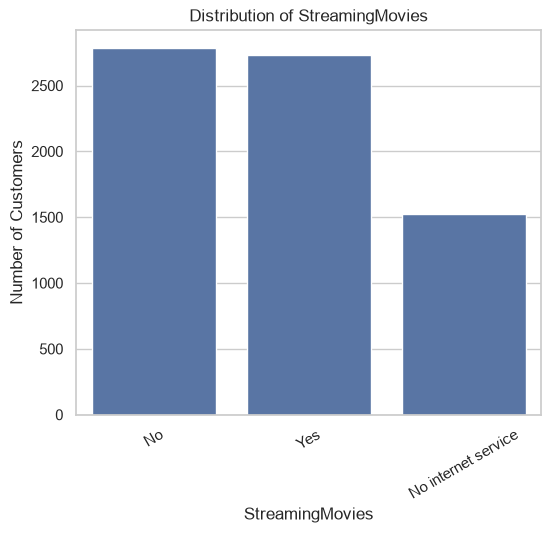

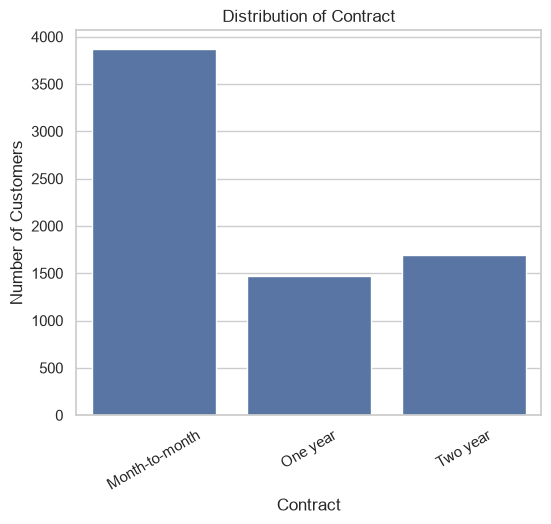

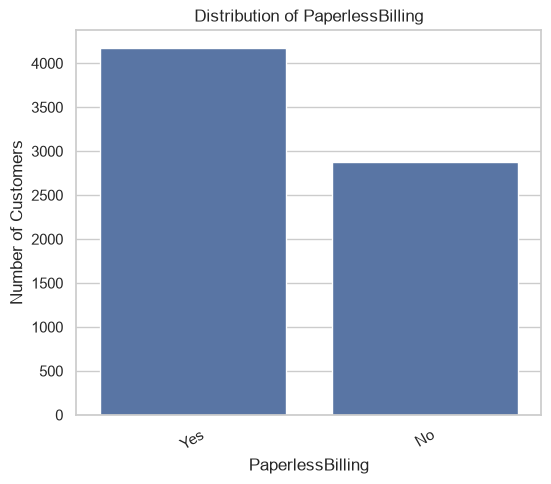

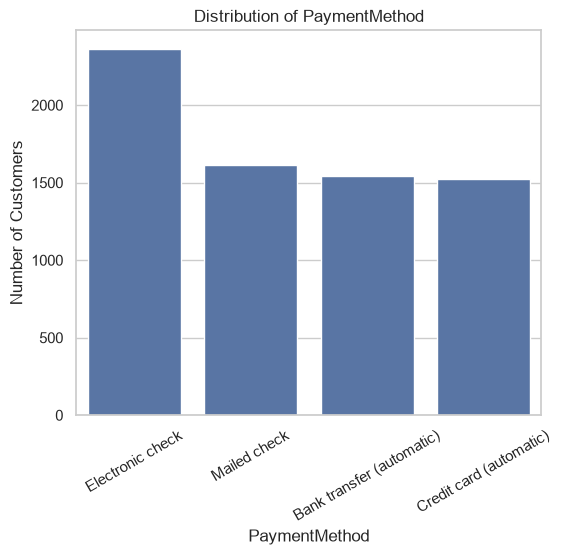

In [50]:
# Distribution of categorical variables
categorical_columns = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

for col in categorical_columns:
    plt.figure(figsize=(6, 5))
    
    sns.countplot(data=df_analysis, x=col)
    
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Number of Customers')
    plt.xticks(rotation=30)
    
    plt.show()

### Observation — Gender Distribution

- The distribution of customers across gender categories is nearly balanced.
- Male customers are slightly more numerous than female customers.
- Therefore, gender does not show a major imbalance in the customer dataset.

### Observation — Senior Citizen Distribution

- The majority of customers are non-senior citizens.
- Senior citizens represent a considerably smaller portion of the customer base.
- This indicates that the dataset is predominantly composed of younger/non-senior customers.

### Observation — Partner Distribution

- Customers without a partner are slightly more numerous than customers with a partner.
- Both categories have substantial representation in the dataset.
- The distribution is therefore moderately balanced, although customers without partners form the larger group.

### Observation — Dependents Distribution

- Most customers do not have dependents.
- Customers with dependents form a considerably smaller segment of the dataset.
- This shows that the customer base is predominantly composed of customers without dependents.

### Observation — Phone Service Distribution

- The vast majority of customers have phone service.
- Only a small proportion of customers do not have phone service.
- Phone service is therefore a common feature among the customers in the dataset.

### Observation — Multiple Lines Distribution

- Customers with no multiple-line service form the largest group.
- Customers with multiple lines represent the second-largest group.
- Only a relatively small number of customers have no phone service.
- This indicates that most customers who use phone service do not necessarily subscribe to multiple lines.

### Observation — Internet Service Distribution

- Fiber optic is the most common internet service among customers.
- DSL is the second most common internet service.
- A smaller group of customers does not have internet service.
- Therefore, internet users form the majority of the customer base, with fiber optic being the dominant service type.

### Observation — Online Security Distribution

- Customers without online security form the largest group.
- Customers with online security represent a smaller portion of the dataset.
- Customers without internet service form the smallest category.
- Overall, online security adoption is lower than the number of customers who do not have this service.

### Observation — Online Backup Distribution

- Customers without online backup form the largest group.
- Customers with online backup are also substantially represented.
- Customers without internet service form the smallest group.
- The graph indicates that online backup is used by a significant but smaller portion of customers compared with those without the service.

### Observation — Device Protection Distribution

- Customers without device protection form the largest category.
- Customers with device protection form the second-largest category.
- Customers without internet service represent the smallest group.
- Device protection is therefore not adopted by the majority of customers.

### Observation — Tech Support Distribution

- Most customers do not have tech support.
- Customers with tech support form a smaller group.
- Customers without internet service represent the smallest category.
- This indicates relatively lower adoption of the tech support service among customers.

### Observation — Streaming TV Distribution

- Customers without streaming TV and customers with streaming TV have relatively similar representation.
- Customers without streaming TV are slightly more numerous.
- Customers without internet service form a smaller segment.
- Overall, streaming TV usage is fairly evenly distributed between customers who subscribe and those who do not.

### Observation — Streaming Movies Distribution

- Customers without streaming movies and customers with streaming movies have very similar representation.
- Customers without streaming movies are slightly more numerous.
- Customers without internet service form the smallest category.
- The distribution suggests that streaming movie usage is relatively balanced among internet-service customers.

### Observation — Contract Distribution

- Month-to-month contracts are the most common contract type by a substantial margin.
- Two-year contracts are the second-largest group.
- One-year contracts have the smallest representation.
- Therefore, the customer base is strongly dominated by month-to-month contracts.

### Observation — Paperless Billing Distribution

- More customers use paperless billing than traditional billing.
- Paperless billing represents the majority of customers.
- However, a considerable number of customers still use non-paperless billing.
- This indicates relatively high adoption of paperless billing in the dataset.

### Observation — Payment Method Distribution

- Electronic check is the most commonly used payment method.
- Mailed check is the second most common method.
- Bank transfer and credit card payments have relatively similar representation.
- Electronic check therefore has noticeably higher usage compared with the other payment methods.

## 9.4 Churn vs Numerical Variables — Bivariate Analysis

Bivariate analysis is performed to examine the relationship between customer churn and numerical variables.

The distributions of Tenure, Monthly Charges, and Total Charges are compared across churned and non-churned customers using appropriate visualizations.

This analysis helps identify whether customer tenure and billing-related variables show noticeable differences between customers who churned and those who remained.

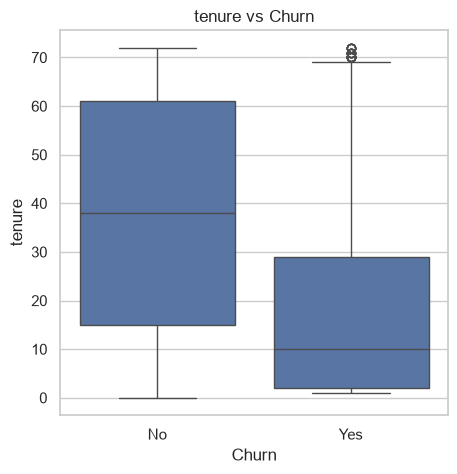

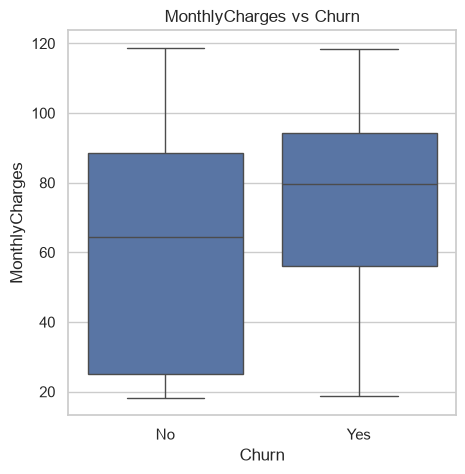

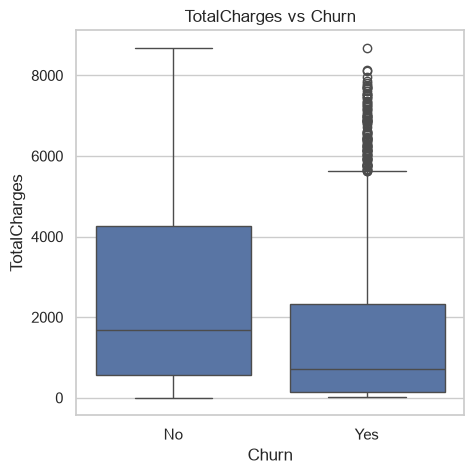

In [51]:
# Churn vs Numerical Variables

numerical_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numerical_columns:
    plt.figure(figsize=(5, 5))
    
    sns.boxplot(data=df_analysis, x='Churn', y=col)
    
    plt.title(f'{col} vs Churn')
    plt.xlabel('Churn')
    plt.ylabel(col)
    
    plt.show()

### Observation — Tenure vs Churn

- Customers who did not churn generally have higher tenure values.
- The median tenure of non-churned customers is substantially higher than that of churned customers.
- Churned customers are concentrated more strongly at lower tenure values.
- This suggests that customers with shorter tenure are more frequently associated with churn.
- Non-churned customers also show a wider distribution toward longer tenure periods.

### Observation — Monthly Charges vs Churn

- Customers who churned generally have higher monthly charges than customers who did not churn.
- The median monthly charge for churned customers is higher than the median for non-churned customers.
- Both groups show considerable variation in monthly charges.
- The graph suggests that higher monthly charges may be associated with increased churn tendency.

### Observation — Total Charges vs Churn

- Customers who did not churn generally have higher total charges than customers who churned.
- The median total charge is substantially higher for non-churned customers.
- Churned customers are concentrated more heavily at lower total-charge values.
- The churned group also contains several high-value outliers.
- The pattern is consistent with the effect of tenure, since customers who remain longer with the company have more time to accumulate total charges.

## 9.5 Churn vs Categorical Variables — Bivariate Analysis

Bivariate analysis is performed to examine the relationship between customer churn and categorical variables.

The churn rate across different demographic, service-related, contract, and payment categories is analyzed using count plots.

This analysis helps identify customer segments and service characteristics that may be associated with higher or lower churn.

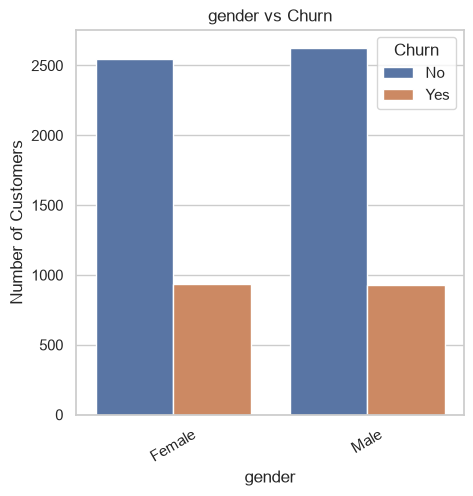

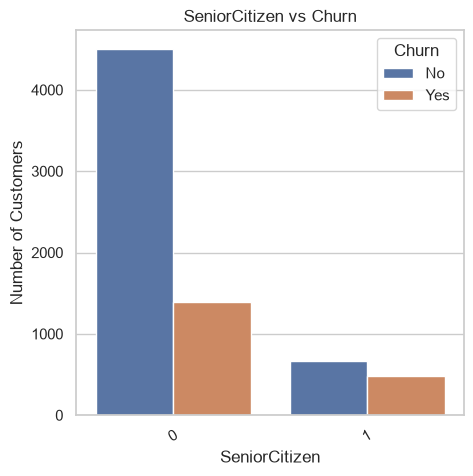

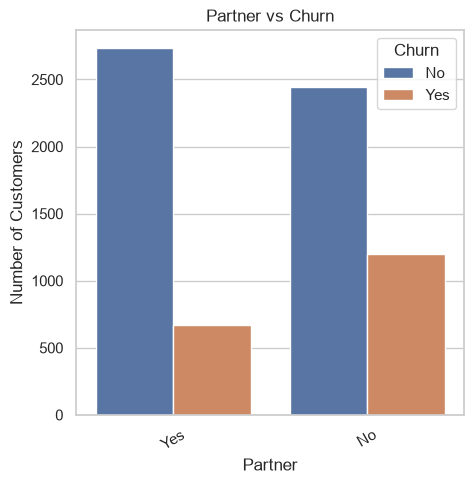

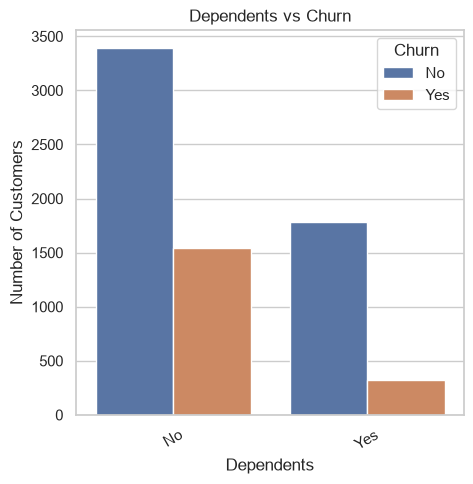

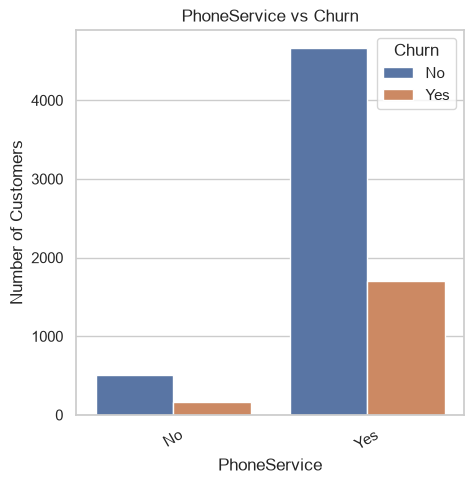

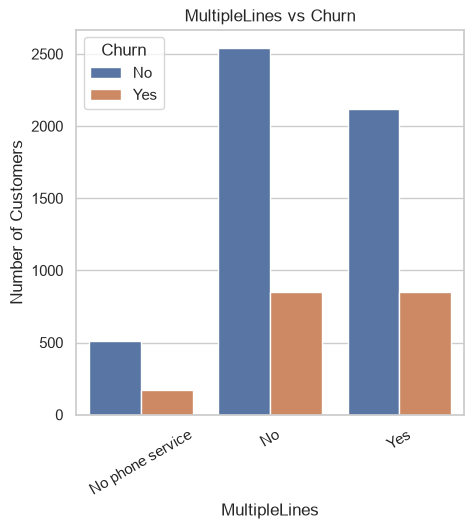

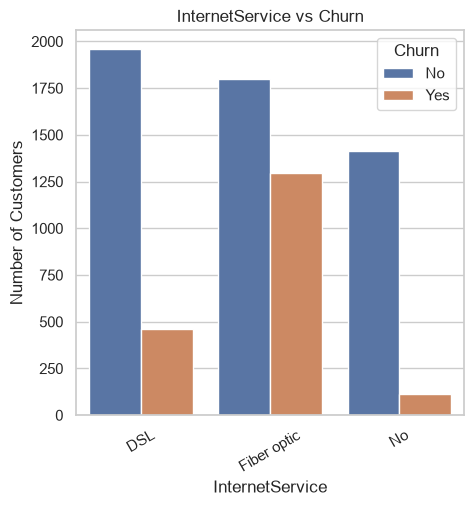

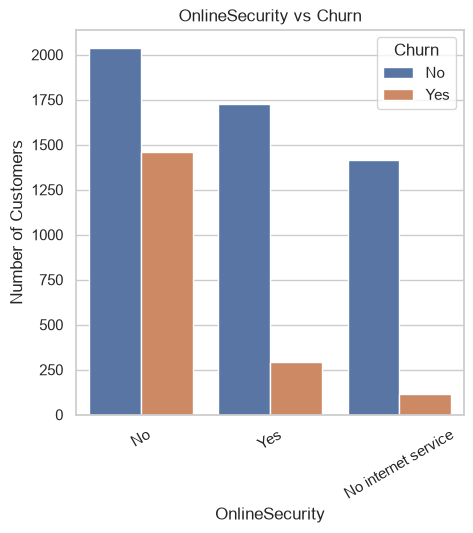

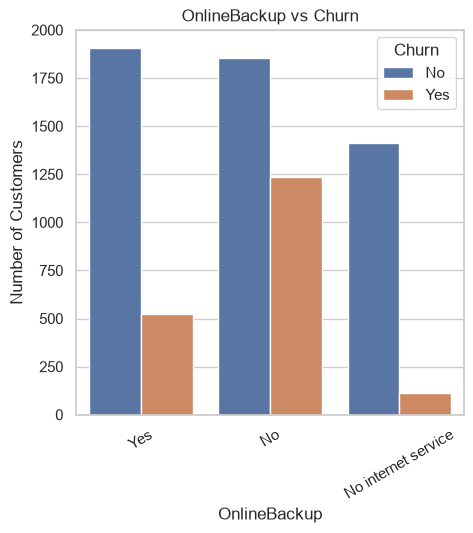

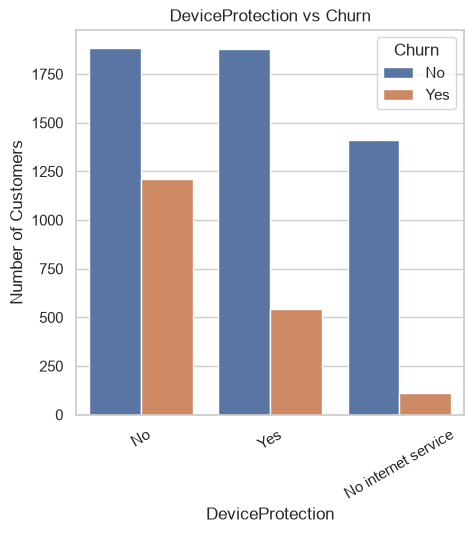

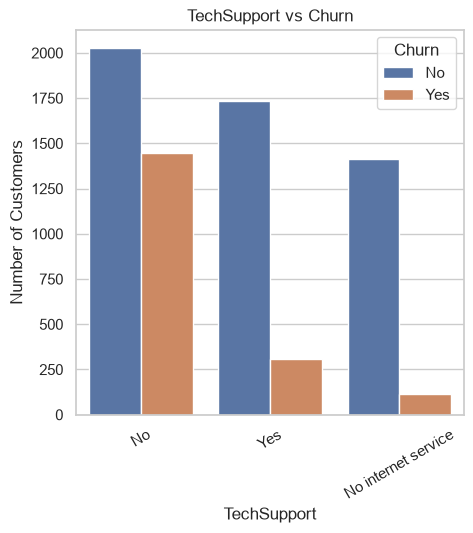

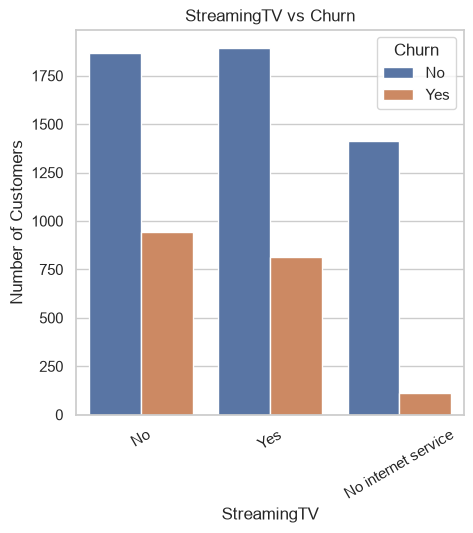

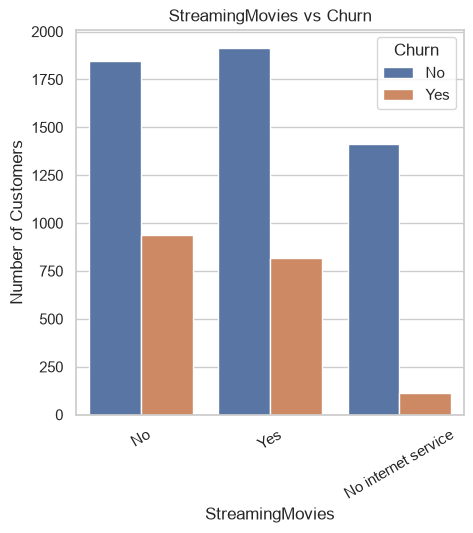

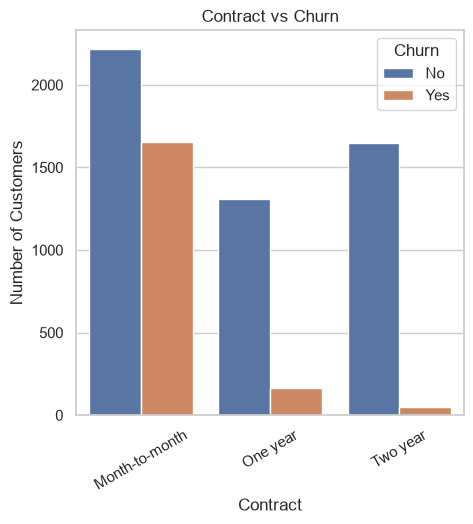

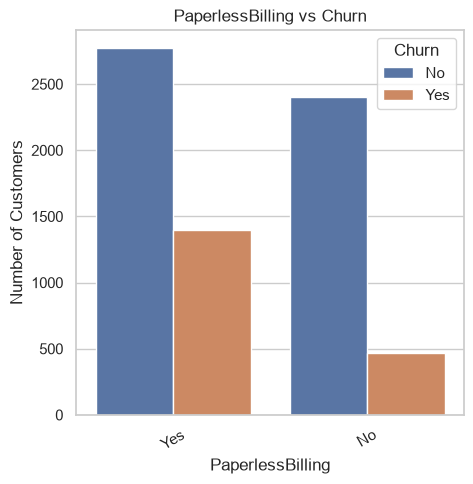

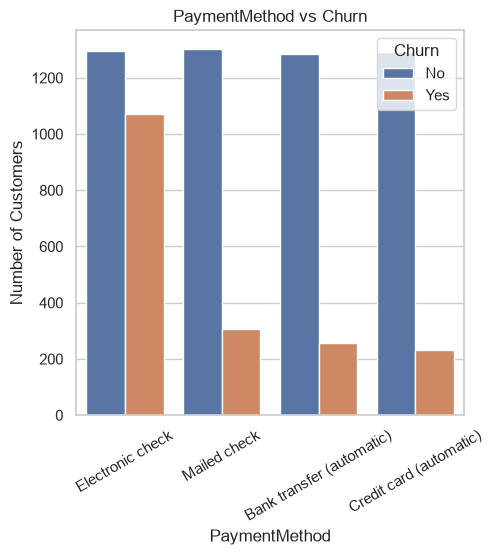

In [52]:
# Churn vs Categorical Variables

categorical_columns = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

for col in categorical_columns:
    plt.figure(figsize=(5, 5))
    
    sns.countplot(data=df_analysis, x=col, hue='Churn')
    
    plt.title(f'{col} vs Churn')
    plt.xlabel(col)
    plt.ylabel('Number of Customers')
    plt.xticks(rotation=30)
    plt.legend(title='Churn')
    
    plt.show()

### Observation — Gender vs Churn

- Both male and female customers contain substantial numbers of churned and non-churned customers.
- The number of non-churned customers is higher than the number of churned customers for both genders.
- The overall distributions for males and females appear broadly similar.
- Based on the count plot alone, gender does not show a strong visual difference in churn behavior.

### Observation — Senior Citizen vs Churn

- Non-senior customers form the majority of both churned and non-churned customers.
- Senior citizens represent a much smaller customer segment.
- Within the senior-citizen group, churned customers form a noticeable portion of the group.
- Since the category sizes are different, churn rates should be calculated separately to make a precise comparison.

### Observation — Partner vs Churn

- Customers without partners form a larger customer population than customers with partners.
- Both groups contain churned and non-churned customers.
- The number of churned customers is visibly higher among customers without partners.
- However, because the underlying group sizes differ, churn rates should be used for a more accurate comparison.

### Observation — Dependents vs Churn

- Customers without dependents form the larger customer group.
- The number of churned customers is considerably higher among customers without dependents.
- Customers with dependents show fewer churned customers.
- The difference in group sizes should be considered before interpreting this as a difference in churn rate.

### Observation — Phone Service vs Churn

- Customers with phone service make up the overwhelming majority of the dataset.
- Consequently, both churned and non-churned customers with phone service are much more numerous.
- Customers without phone service represent a relatively small segment.
- The count plot alone does not indicate that phone service itself causes higher or lower churn.

### Observation — Multiple Lines vs Churn

- Customers with no multiple-line service form the largest group, followed by customers with multiple lines.
- Both groups contain substantial numbers of churned customers.
- Customers without phone service form a much smaller group and have relatively few churned customers.
- Because the category sizes differ, churn rates would provide a better comparison between these groups.

### Observation — Internet Service vs Churn

- Fiber optic customers show a large number of churned customers.
- DSL customers also contain churned customers, but the count is lower than that of fiber optic customers.
- Customers without internet service have comparatively few churned customers.
- The graph indicates that internet-service type may be an important variable for further churn analysis.

### Observation — Online Security vs Churn

- Customers without online security have the largest number of churned customers.
- Customers with online security have considerably fewer churned customers.
- Customers without internet service have the smallest number of churned customers.
- This suggests that online security status may be relevant to churn behavior and should be investigated further using churn-rate calculations.

### Observation — Online Backup vs Churn

- Customers without online backup have a large number of churned customers.
- Customers with online backup also show a substantial number of churned customers.
- Customers without internet service have comparatively few churned customers.
- The difference in category sizes means that churn counts should not be interpreted directly as churn rates.

### Observation — Device Protection vs Churn

- Customers without device protection have a larger number of churned customers than customers with device protection.
- Customers without internet service have relatively few churned customers.
- The graph suggests a possible relationship between device-protection status and churn.
- Further analysis using churn rates would provide a more reliable comparison.

### Observation — Tech Support vs Churn

- Customers without tech support show the largest number of churned customers.
- Customers with tech support have substantially fewer churned customers.
- Customers without internet service have the smallest number of churned customers.
- The pattern suggests that tech support status may be associated with customer churn and warrants further investigation.

### Observation — Streaming TV vs Churn

- Both customers with and without streaming TV contain substantial numbers of churned customers.
- The number of churned customers is somewhat higher among customers without streaming TV.
- Customers without internet service have relatively few churned customers.
- The relatively similar distributions suggest that streaming TV may have a weaker visual association with churn compared with variables such as contract type.

### Observation — Streaming Movies vs Churn

- Both customers with and without streaming movies contain substantial numbers of churned customers.
- The number of churned customers is somewhat higher among customers without streaming movies.
- Customers without internet service have comparatively few churned customers.
- The visual difference is not as pronounced as that observed for some other service-related variables.

### Observation — Contract vs Churn

- Month-to-month customers have by far the largest number of churned customers.
- One-year contract customers have considerably fewer churned customers.
- Two-year contract customers have the smallest number of churned customers.
- The graph shows a clear association between contract type and churn behavior.
- Contract type appears to be one of the more important categorical variables for further churn analysis.

### Observation — Paperless Billing vs Churn

- Customers using paperless billing have a substantially larger number of churned customers.
- Customers not using paperless billing have fewer churned customers.
- Since paperless billing also represents the larger customer group, churn rates should be calculated before drawing a definitive conclusion about its effect on churn.

### Observation — Payment Method vs Churn

- Electronic check has the largest number of churned customers among the payment methods.
- Mailed check, bank transfer, and credit card customers have considerably fewer churned customers.
- The difference is particularly noticeable between electronic check and the other payment methods.
- Payment method therefore appears to be an important variable for further investigation of customer churn.

## 9.6 Correlation Analysis

Correlation analysis is performed to examine the strength and direction of relationships between numerical variables in the dataset.

A correlation matrix and heatmap are used to identify positive and negative relationships among variables such as tenure, monthly charges, total charges, and churn-related numerical representations.

This analysis helps identify variables that may provide useful information for further statistical analysis and predictive modeling.

Correlation Matrix:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.103006
tenure,0.016567,1.000000,0.247900,0.826178
MonthlyCharges,0.220173,0.247900,1.000000,0.651174
TotalCharges,0.103006,0.826178,0.651174,1.000000


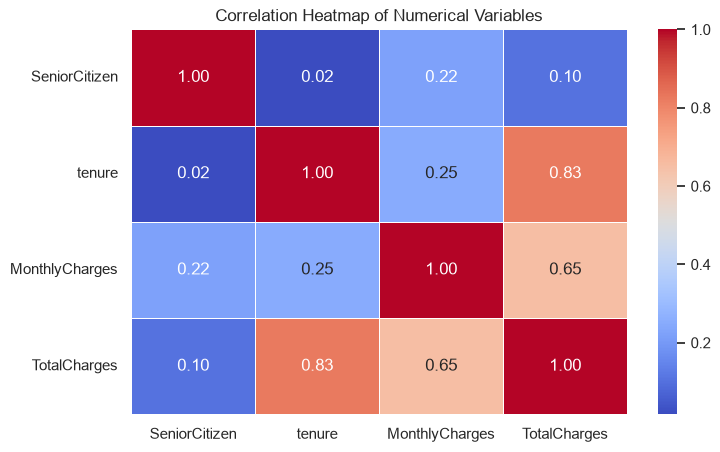

In [53]:
# Correlation Analysis

# Select numerical columns
numerical_df = df_analysis.select_dtypes(include=['int64', 'float64'])

# Calculate correlation matrix
correlation_matrix = numerical_df.corr()

# Display correlation matrix
print("Correlation Matrix:")
display(correlation_matrix)

# Plot correlation heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

### Observation :

- Tenure and TotalCharges have a strong positive correlation of approximately 0.83.
- MonthlyCharges and TotalCharges show a moderate positive correlation of approximately 0.65.
- Tenure and MonthlyCharges have a relatively weak positive correlation of approximately 0.25.
- SeniorCitizen has only weak correlations with the other numerical variables.
- The strongest relationship in the heatmap is between Tenure and TotalCharges, which is expected because customers with longer tenure generally accumulate higher total charges.
- Overall, the heatmap indicates that TotalCharges is more strongly associated with Tenure and MonthlyCharges than with SeniorCitizen.

### Key Findings from EDA

- The customer base is relatively balanced by gender but is predominantly composed of non-senior customers and customers without dependents.
- Most customers have phone service and internet service, with fiber optic being the most common internet service.
- Month-to-month contracts are substantially more common than one-year and two-year contracts.
- Customers who churn generally have lower tenure and lower total charges, while their monthly charges tend to be higher than those of non-churned customers.
- Several categorical variables show noticeable differences in churn counts, particularly contract type, internet service, online security, tech support, and payment method.
- Month-to-month contracts and electronic-check payment show particularly noticeable numbers of churned customers.
- The correlation analysis shows a strong positive relationship between tenure and total charges, while most other numerical relationships are relatively weak to moderate.
- Overall, EDA indicates that customer tenure, monthly charges, contract type, internet-service characteristics, and payment-related variables may provide useful information for subsequent churn analysis and predictive modeling.

#  10. Statistical Analysis

Statistical analysis is performed to identify significant relationships and differences between customer characteristics and churn behavior.

This section uses statistical methods to validate patterns observed during Exploratory Data Analysis (EDA) and determine whether the observed relationships are statistically significant.

The analysis will focus on hypothesis testing and statistical relationships between selected customer attributes and the target variable, Churn.

## 10.1 Hypothesis Testing — Churn and Contract Type

A Chi-Square Test of Independence is used to determine whether there is a statistically significant association between customer churn and contract type.

### Hypotheses

- **Null Hypothesis (H₀):** Churn and Contract Type are independent of each other.
- **Alternative Hypothesis (H₁):** Churn and Contract Type are not independent of each other.

A significance level of **5% (α = 0.05)** is used for the hypothesis test.

In [54]:
# Chi-Square Test: Churn vs Contract Type
from scipy.stats import chi2_contingency
# Create contingency table
contingency_table = pd.crosstab(
    df_analysis['Contract'],
    df_analysis['Churn']
)

print("Contingency Table:")
display(contingency_table)

# Perform Chi-Square test
chi2, p_value, degrees_of_freedom, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of Freedom: {degrees_of_freedom}")

# Decision
alpha = 0.05

if p_value < alpha:
    print("Result: Reject the Null Hypothesis.")
    print("There is a statistically significant association between Contract Type and Churn.")
else:
    print("Result: Fail to Reject the Null Hypothesis.")
    print("There is no statistically significant association between Contract Type and Churn.")

Contingency Table:


Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


Chi-Square Statistic: 1184.5966
P-value: 0.0000
Degrees of Freedom: 2
Result: Reject the Null Hypothesis.
There is a statistically significant association between Contract Type and Churn.


## 10.2 Hypothesis Testing — Churn and Internet Service

A Chi-Square Test of Independence is used to determine whether there is a statistically significant association between Internet Service and customer Churn.

### Hypotheses

- **Null Hypothesis (H₀):** Internet Service and Churn are independent of each other.
- **Alternative Hypothesis (H₁):** Internet Service and Churn are not independent of each other.

A significance level of **5% (α = 0.05)** is used for the hypothesis test.

In [55]:
# Chi-Square Test: Churn vs Internet Service
from scipy.stats import chi2_contingency

# Create contingency table
contingency_table = pd.crosstab(
    df_analysis['InternetService'],
    df_analysis['Churn']
)

print("Contingency Table:")
display(contingency_table)

# Perform Chi-Square test
chi2, p_value, degrees_of_freedom, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of Freedom: {degrees_of_freedom}")

# Decision
alpha = 0.05

if p_value < alpha:
    print("Result: Reject the Null Hypothesis.")
    print("There is a statistically significant association between Internet Service and Churn.")
else:
    print("Result: Fail to Reject the Null Hypothesis.")
    print("There is no statistically significant association between Internet Service and Churn.")

Contingency Table:


Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


Chi-Square Statistic: 732.3096
P-value: 0.0000
Degrees of Freedom: 2
Result: Reject the Null Hypothesis.
There is a statistically significant association between Internet Service and Churn.


## 10.3 Hypothesis Testing — Churn and Payment Method

A Chi-Square Test of Independence is used to determine whether there is a statistically significant association between Payment Method and customer Churn.

### Hypotheses

- **Null Hypothesis (H₀):** Payment Method and Churn are independent of each other.
- **Alternative Hypothesis (H₁):** Payment Method and Churn are not independent of each other.

A significance level of **5% (α = 0.05)** is used for the hypothesis test.

In [56]:
# Chi-Square Test: Churn vs Payment Method
from scipy.stats import chi2_contingency

# Create contingency table
contingency_table = pd.crosstab(
    df_analysis['PaymentMethod'],
    df_analysis['Churn']
)

print("Contingency Table:")
display(contingency_table)

# Perform Chi-Square test
chi2, p_value, degrees_of_freedom, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of Freedom: {degrees_of_freedom}")

# Decision
alpha = 0.05

if p_value < alpha:
    print("Result: Reject the Null Hypothesis.")
    print("There is a statistically significant association between Payment Method and Churn.")
else:
    print("Result: Fail to Reject the Null Hypothesis.")
    print("There is no statistically significant association between Payment Method and Churn.")

Contingency Table:


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


Chi-Square Statistic: 648.1423
P-value: 0.0000
Degrees of Freedom: 3
Result: Reject the Null Hypothesis.
There is a statistically significant association between Payment Method and Churn.


## 10.4 Hypothesis Testing — Tenure and Churn

An independent samples t-test is used to determine whether there is a statistically significant difference in the average tenure between customers who churned and customers who did not churn.

### Hypotheses

- **Null Hypothesis (H₀):** There is no significant difference in the mean tenure of churned and non-churned customers.
- **Alternative Hypothesis (H₁):** There is a significant difference in the mean tenure of churned and non-churned customers.

A significance level of **5% (α = 0.05)** is used for the hypothesis test.

In [57]:
# Independent Samples T-Test: Tenure vs Churn
from scipy.stats import ttest_ind

# Separate tenure values by churn status
tenure_no_churn = df_analysis[df_analysis['Churn'] == 'No']['tenure']
tenure_churn = df_analysis[df_analysis['Churn'] == 'Yes']['tenure']

# Perform independent samples t-test
t_statistic, p_value = ttest_ind(
    tenure_no_churn,
    tenure_churn,
    equal_var=False
)

print(f"Mean Tenure - No Churn: {tenure_no_churn.mean():.2f}")
print(f"Mean Tenure - Churn: {tenure_churn.mean():.2f}")
print(f"T-Statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# Decision
alpha = 0.05

if p_value < alpha:
    print("Result: Reject the Null Hypothesis.")
    print("There is a statistically significant difference in mean tenure between churned and non-churned customers.")
else:
    print("Result: Fail to Reject the Null Hypothesis.")
    print("There is no statistically significant difference in mean tenure between churned and non-churned customers.")

Mean Tenure - No Churn: 37.57
Mean Tenure - Churn: 17.98
T-Statistic: 34.8238
P-value: 0.0000
Result: Reject the Null Hypothesis.
There is a statistically significant difference in mean tenure between churned and non-churned customers.


## 10.5 Hypothesis Testing — Monthly Charges and Churn

An independent samples t-test is used to determine whether there is a statistically significant difference in the average monthly charges between customers who churned and customers who did not churn.

### Hypotheses

- **Null Hypothesis (H₀):** There is no significant difference in the mean monthly charges of churned and non-churned customers.
- **Alternative Hypothesis (H₁):** There is a significant difference in the mean monthly charges of churned and non-churned customers.

A significance level of **5% (α = 0.05)** is used for the hypothesis test.

In [58]:
# Independent Samples T-Test: Monthly Charges vs Churn

from scipy.stats import ttest_ind

# Separate monthly charges by churn status
charges_no_churn = df_analysis[df_analysis['Churn'] == 'No']['MonthlyCharges']
charges_churn = df_analysis[df_analysis['Churn'] == 'Yes']['MonthlyCharges']

# Perform Welch's independent samples t-test
t_statistic, p_value = ttest_ind(
    charges_no_churn,
    charges_churn,
    equal_var=False
)

print(f"Mean Monthly Charges - No Churn: {charges_no_churn.mean():.2f}")
print(f"Mean Monthly Charges - Churn: {charges_churn.mean():.2f}")
print(f"T-Statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# Decision
alpha = 0.05

if p_value < alpha:
    print("Result: Reject the Null Hypothesis.")
    print("There is a statistically significant difference in mean monthly charges between churned and non-churned customers.")
else:
    print("Result: Fail to Reject the Null Hypothesis.")
    print("There is no statistically significant difference in mean monthly charges between churned and non-churned customers.")

Mean Monthly Charges - No Churn: 61.27
Mean Monthly Charges - Churn: 74.44
T-Statistic: -18.4075
P-value: 0.0000
Result: Reject the Null Hypothesis.
There is a statistically significant difference in mean monthly charges between churned and non-churned customers.


## 10.6 Statistical Analysis Summary

Statistical hypothesis testing was performed to validate the relationships between selected customer characteristics and churn behavior.

The analysis included Chi-Square Tests of Independence for categorical variables and independent samples t-tests for numerical variables.

The statistical tests conducted were:

* **Contract Type vs Churn:** A statistically significant association was found between contract type and churn.
* **Internet Service vs Churn:** A statistically significant association was found between internet service and churn.
* **Payment Method vs Churn:** A statistically significant association was found between payment method and churn.
* **Tenure vs Churn:** A statistically significant difference was found in the mean tenure between churned and non-churned customers.
* **Monthly Charges vs Churn:** A statistically significant difference was found in the mean monthly charges between churned and non-churned customers.

Using a significance level of **5% (α = 0.05)**, all hypothesis tests resulted in rejecting the null hypothesis.

These findings statistically support several patterns identified during the Exploratory Data Analysis (EDA) and provide a foundation for the subsequent feature engineering and machine learning stages.


# 11. Feature Engineering

Feature engineering is the process of transforming and preparing the existing dataset into suitable features for machine learning models.

In this step, categorical variables will be converted into numerical representations, while the existing numerical variables will be prepared for modeling.

The goal is to create a machine-learning-ready dataset while preserving the important information present in the original data.


## 11.1 Encoding Categorical Variables

Machine learning algorithms require categorical variables to be represented in numerical form.

In this step, categorical features will be converted into numerical values using **One-Hot Encoding**. This creates separate binary columns for each category and allows categorical information to be used effectively by machine learning models.


In [59]:
# Encode categorical variables using One-Hot Encoding

df_encoded = pd.get_dummies(
    df_analysis,
    columns=df_analysis.select_dtypes(include='object').columns,
    drop_first=True
)

print("Encoded Dataset Shape:", df_encoded.shape)
display(df_encoded.head())

Encoded Dataset Shape: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True


## 11.2 Target Variable Preparation

The target variable, **Churn**, represents whether a customer has discontinued the service.

Since machine learning models require the target variable to be represented numerically, the encoded **Churn_Yes** column will be separated from the feature variables.

* **0** represents customers who did not churn.
* **1** represents customers who churned.

The remaining columns will be used as independent features for building the predictive models.


In [60]:
# Separate features and target variable

X = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes'].astype(int)

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nTarget Variable Distribution:")
print(y.value_counts())

Features Shape: (7043, 30)
Target Shape: (7043,)

Target Variable Distribution:
Churn_Yes
0    5174
1    1869
Name: count, dtype: int64


## 11.3 Feature Scaling

Feature scaling is used to bring numerical features to a comparable scale before applying machine learning algorithms.

In this step, **StandardScaler** is used to standardize the numerical features so that they have a mean of approximately 0 and a standard deviation of approximately 1.

Scaling helps prevent variables with larger numerical ranges, such as **TotalCharges**, from disproportionately influencing distance-based and optimization-based machine learning algorithms.

Categorical dummy variables are retained in their binary form.


In [61]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

# Numerical columns
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Create a copy of the feature dataset
X_scaled = X.copy()

# Initialize StandardScaler
scaler = StandardScaler()

# Scale numerical features
X_scaled[numerical_features] = scaler.fit_transform(
    X_scaled[numerical_features]
)

print("Feature scaling completed successfully.")

print("\nScaled Numerical Features:")
display(X_scaled[numerical_features].head())

Feature scaling completed successfully.

Scaled Numerical Features:


,tenure,MonthlyCharges,TotalCharges
0,-1.277445,-1.160323,-0.992611
1,0.066327,-0.259629,-0.172165
2,-1.236724,-0.362660,-0.958066
3,0.514251,-0.746535,-0.193672
4,-1.236724,0.197365,-0.938874


## 11.4 Train-Test Split

The dataset is divided into training and testing sets to evaluate the performance of machine learning models on unseen data.

An **80:20 split** is used, where 80% of the data is used for training and 20% is reserved for testing.

Stratification is applied to maintain the same proportion of churned and non-churned customers in both datasets.


In [62]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (5634, 30)
Testing Features Shape: (1409, 30)
Training Target Shape: (5634,)
Testing Target Shape: (1409,)


#  12. Data Preparation for Machine Learning

In this step, the cleaned dataset will be prepared for machine learning. The categorical variables will be converted into numerical form, the data will be separated into input features and the target variable, and the dataset will be split into training and testing sets. Feature scaling will also be performed where required to ensure that the variables are on an appropriate scale for model training.

The main objectives of this step are:

* Encode categorical variables into numerical values.
* Separate the independent variables (`X`) from the target variable (`y`).
* Split the dataset into training and testing sets.
* Scale numerical features where required.
* Prepare the final datasets for machine learning model development.


## 12.1 Checking Class Distribution

Before building the machine learning models, the distribution of the target variable in the training dataset is examined.

The **Churn** variable contains two classes: customers who did not churn and customers who churned.

Since the dataset has an imbalanced target variable, the class distribution will be evaluated to determine whether additional techniques are required to address class imbalance during model training.


In [63]:
# Check class distribution in the training set

print("Training Set Class Distribution:")
print(y_train.value_counts())

print("\nTraining Set Class Proportion:")
print(y_train.value_counts(normalize=True))

Training Set Class Distribution:
Churn_Yes
0    4139
1    1495
Name: count, dtype: int64

Training Set Class Proportion:
Churn_Yes
0    0.734647
1    0.265353
Name: proportion, dtype: float64


## 12.2 Handling Class Imbalance

The training dataset contains an imbalanced target variable, with non-churned customers representing approximately 73.46% of the training data and churned customers representing approximately 26.54%.

To address this imbalance, **class weighting** will be used during model training. The `class_weight='balanced'` option assigns greater weight to the minority churn class and helps the models pay appropriate attention to both classes.

The original training data will be retained without artificially generating additional observations.


## 12.3 Final ML Dataset Check

Before building the machine learning models, the training and testing datasets are checked to confirm their dimensions and ensure that the features and target variables are correctly separated.

This final check helps verify that the data is properly prepared and ready for model building.


In [64]:
# Final check before model building

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nMissing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())
print("Missing values in y_train:", y_train.isnull().sum())
print("Missing values in y_test:", y_test.isnull().sum())

X_train shape: (5634, 30)
X_test shape: (1409, 30)
y_train shape: (5634,)
y_test shape: (1409,)

Missing values in X_train: 0
Missing values in X_test: 0
Missing values in y_train: 0
Missing values in y_test: 0


# 13.  Model Building

In this step, machine learning models will be built using the prepared training dataset. Different classification algorithms will be trained to predict whether a customer is likely to churn.

The main objectives of this step are:

* Train machine learning classification models on the prepared data.
* Apply the selected algorithms to the customer churn prediction problem.
* Generate predictions using the trained models.
* Compare the performance of the models using appropriate evaluation metrics.
* Identify the model that provides the most suitable performance for the churn prediction task.


## 13.1 Logistic Regression

Logistic Regression is used as a baseline classification model for predicting customer churn.

It estimates the probability that a customer will churn based on the available customer and service-related features.

The model is trained using the training dataset, with **class weighting** applied to address the imbalance between churned and non-churned customers.


In [65]:
# 13.1 Logistic Regression

from sklearn.linear_model import LogisticRegression

# Initialize the model
logistic_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train, y_train)

# Make predictions
y_pred_logistic = logistic_model.predict(X_test)

print("Logistic Regression model trained successfully.")
print("Predictions generated successfully.")

Logistic Regression model trained successfully.
Predictions generated successfully.


## 13.2 Decision Tree

A Decision Tree is a supervised machine learning algorithm that makes predictions by dividing the data into a series of decision rules.

It is used to identify patterns associated with customer churn and provides an interpretable model that can capture non-linear relationships between features and the target variable.

Class weighting is applied to give greater importance to the minority churn class.


In [66]:
# 13.2 Decision Tree

from sklearn.tree import DecisionTreeClassifier

# Initialize the model
decision_tree_model = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

# Train the model
decision_tree_model.fit(X_train, y_train)

# Make predictions
y_pred_tree = decision_tree_model.predict(X_test)

print("Decision Tree model trained successfully.")
print("Predictions generated successfully.")

Decision Tree model trained successfully.
Predictions generated successfully.


## 13.3 Random Forest

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to improve prediction performance and reduce the risk of overfitting.

It is suitable for customer churn prediction because it can capture complex relationships between customer characteristics and churn behavior.

Class weighting is applied to give greater importance to the minority churn class.


In [67]:
# 13.3 Random Forest

from sklearn.ensemble import RandomForestClassifier

# Initialize the model
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

# Train the model
random_forest_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest model trained successfully.")
print("Predictions generated successfully.")

Random Forest model trained successfully.
Predictions generated successfully.


## 13.4 K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a supervised machine learning algorithm that classifies a customer based on the classes of nearby observations.

Since KNN is distance-based, the numerical features were standardized during the feature scaling stage.

The model will be trained using the prepared training dataset and used to predict customer churn.


In [68]:
# 13.4 K-Nearest Neighbors (KNN)

from sklearn.neighbors import KNeighborsClassifier

# Initialize the model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train, y_train)

# Make predictions
y_pred_knn = knn_model.predict(X_test)

print("KNN model trained successfully.")
print("Predictions generated successfully.")

KNN model trained successfully.
Predictions generated successfully.


## 13.5 Support Vector Machine (SVM)

Support Vector Machine (SVM) is a supervised machine learning algorithm that identifies an optimal decision boundary between different classes.

SVM can be effective for binary classification problems such as customer churn prediction, particularly when the features have been appropriately scaled.

The model will be trained on the prepared training dataset and used to predict customer churn.


In [69]:
# 13.5 Support Vector Machine (SVM)

from sklearn.svm import SVC

# Initialize the model
svm_model = SVC(
    class_weight='balanced',
    random_state=42
)

# Train the model
svm_model.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test)

print("SVM model trained successfully.")
print("Predictions generated successfully.")

SVM model trained successfully.
Predictions generated successfully.


## 13.6 Model Building Summary

Five machine learning classification models were trained to predict customer churn:

* **Logistic Regression**
* **Decision Tree**
* **Random Forest**
* **K-Nearest Neighbors (KNN)**
* **Support Vector Machine (SVM)**

The models were trained using the prepared training dataset, with class weighting applied where appropriate to address the imbalance in the target variable.

Predictions were generated on the testing dataset for each model.

The performance of these models will be evaluated and compared in the next step using multiple classification metrics.


# 14. Model Evaluation & Comparison

In this step, the performance of the trained machine learning models will be evaluated and compared. Since this is a customer churn classification problem, appropriate classification metrics will be used to assess how well each model predicts customer churn.

### Objectives:
- Evaluate the performance of each trained model.
- Calculate relevant classification metrics such as Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
- Analyze the confusion matrix to understand correct and incorrect predictions.
- Compare the performance of all models.
- Identify the most suitable model for predicting customer churn.

## 14.1 Model Performance Metrics

The performance of the trained machine learning models is evaluated using multiple classification metrics.

The following metrics are calculated for each model:

* **Accuracy:** Measures the overall proportion of correctly classified customers.
* **Precision:** Measures how accurately the model identifies customers predicted to churn.
* **Recall:** Measures how effectively the model identifies actual churned customers.
* **F1-Score:** Provides a balance between precision and recall.

Since customer churn is an imbalanced classification problem, multiple metrics are considered rather than relying on accuracy alone.


In [70]:
# 14.1 Model Performance Metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Store model predictions
model_predictions = {
    'Logistic Regression': y_pred_logistic,
    'Decision Tree': y_pred_tree,
    'Random Forest': y_pred_rf,
    'KNN': y_pred_knn,
    'SVM': y_pred_svm
}

# Calculate performance metrics
performance_results = []

for model_name, predictions in model_predictions.items():
    performance_results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision': precision_score(y_test, predictions),
        'Recall': recall_score(y_test, predictions),
        'F1-Score': f1_score(y_test, predictions)
    })

# Create performance dataframe
performance_df = pd.DataFrame(performance_results)

# Display results
display(performance_df.round(4))

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.7388,0.5052,0.7834,0.6143
1,Decision Tree,0.7374,0.5055,0.4893,0.4973
2,Random Forest,0.7700,0.5598,0.6257,0.5909
3,KNN,0.7630,0.5538,0.5508,0.5523
4,SVM,0.7459,0.5141,0.7807,0.6200


## 14.2 Confusion Matrices

A confusion matrix is used to examine the classification performance of each machine learning model in greater detail.

It shows the number of:

* **True Negatives (TN):** Non-churned customers correctly identified.
* **False Positives (FP):** Non-churned customers incorrectly classified as churned.
* **False Negatives (FN):** Churned customers incorrectly classified as non-churned.
* **True Positives (TP):** Churned customers correctly identified.

Confusion matrices help evaluate how effectively each model identifies customers who are at risk of churn.


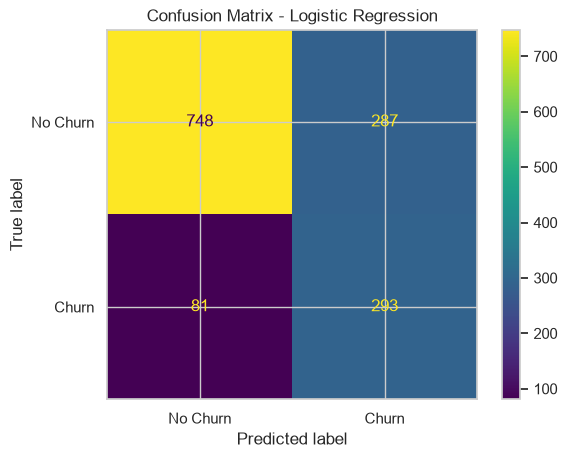

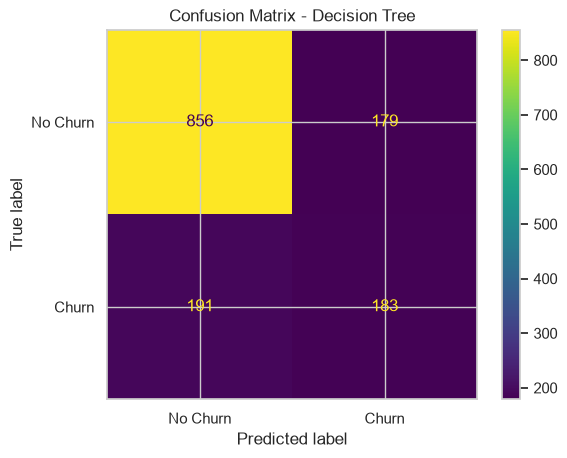

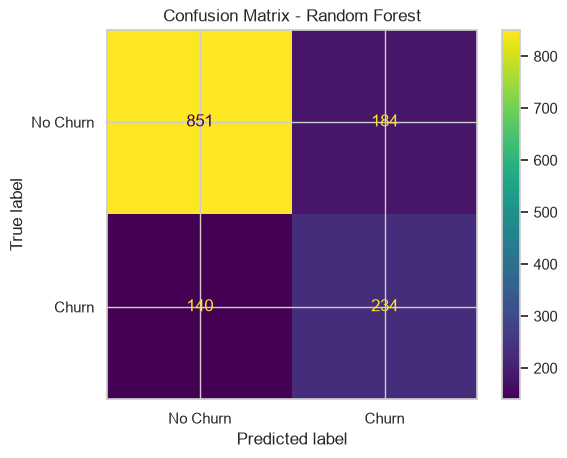

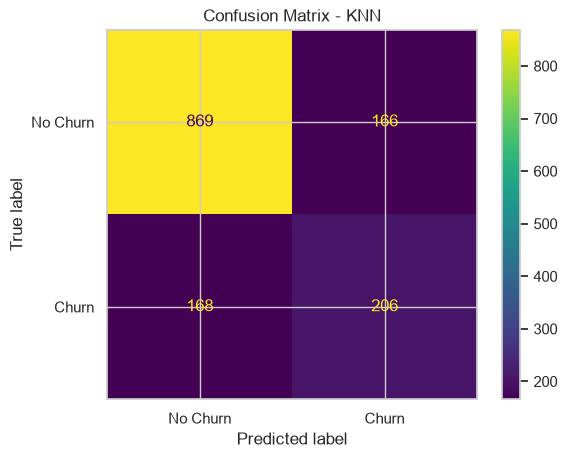

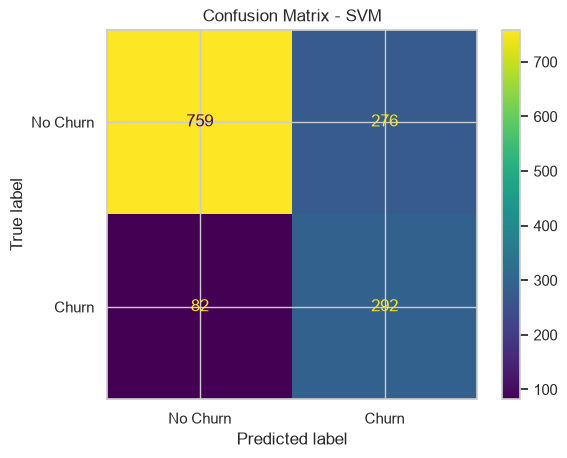

In [71]:
# 14.2 Confusion Matrices

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Store model predictions
model_predictions = {
    'Logistic Regression': y_pred_logistic,
    'Decision Tree': y_pred_tree,
    'Random Forest': y_pred_rf,
    'KNN': y_pred_knn,
    'SVM': y_pred_svm
}

# Plot confusion matrix for each model
for model_name, predictions in model_predictions.items():
    
    cm = confusion_matrix(y_test, predictions)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Churn', 'Churn']
    )
    
    disp.plot()
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

### 14.2.1 Observations — Logistic Regression

* The model correctly classified **748 non-churned customers** and **293 churned customers**.
* It incorrectly classified **287 non-churned customers as churned** (False Positives).
* It incorrectly classified **81 churned customers as non-churned** (False Negatives).
* The relatively low number of false negatives indicates that Logistic Regression is effective at identifying customers who actually churned.
* This is consistent with its high **Recall of 0.7834**.

---

### 14.2.2 Observations — Decision Tree

* The model correctly classified **856 non-churned customers** and **183 churned customers**.
* It produced **179 False Positives** and **191 False Negatives**.
* The relatively high number of false negatives indicates that the Decision Tree misses a considerable number of actual churned customers.
* This is consistent with its comparatively low **Recall of 0.4893** and **F1-Score of 0.4973**.
* Overall, the confusion matrix indicates weaker churn identification compared with the other models.

---

### 14.2.3 Observations — Random Forest

* The model correctly classified **851 non-churned customers** and **234 churned customers**.
* It produced **184 False Positives** and **140 False Negatives**.
* Compared with the Decision Tree, Random Forest identifies more actual churned customers and produces fewer false negatives.
* The model therefore provides a better balance between identifying churned customers and correctly identifying non-churned customers.
* This is reflected in its higher **Accuracy of 0.7700** and **F1-Score of 0.5909**.

---

### 14.2.4 Observations — K-Nearest Neighbors (KNN)

* The model correctly classified **869 non-churned customers** and **206 churned customers**.
* It produced **166 False Positives** and **168 False Negatives**.
* KNN correctly identifies a moderate number of churned customers but still misses a considerable number of actual churn cases.
* Its performance is relatively balanced between false positives and false negatives.
* This corresponds to its moderate **Recall of 0.5508** and **F1-Score of 0.5523**.

---

### 14.2.5 Observations — Support Vector Machine (SVM)

* The model correctly classified **759 non-churned customers** and **292 churned customers**.
* It produced **276 False Positives** and only **82 False Negatives**.
* The low number of false negatives indicates that SVM is highly effective at identifying actual churned customers.
* Its churn detection performance is very close to Logistic Regression, which produced 293 true positives and 81 false negatives.
* This is consistent with its high **Recall of 0.7807** and highest **F1-Score of 0.6200** among the five models.


## 14.3 ROC Curve & AUC

The Receiver Operating Characteristic (ROC) curve is used to evaluate the ability of each classification model to distinguish between churned and non-churned customers across different classification thresholds.

The **Area Under the Curve (AUC)** provides a single measure of the model's overall discriminatory ability.

* An AUC closer to **1.0** indicates better ability to distinguish between the two classes.
* An AUC of approximately **0.5** indicates performance close to random classification.

ROC-AUC scores will be compared across all five models to assess their ability to distinguish customers who are likely to churn from those who are likely to remain.


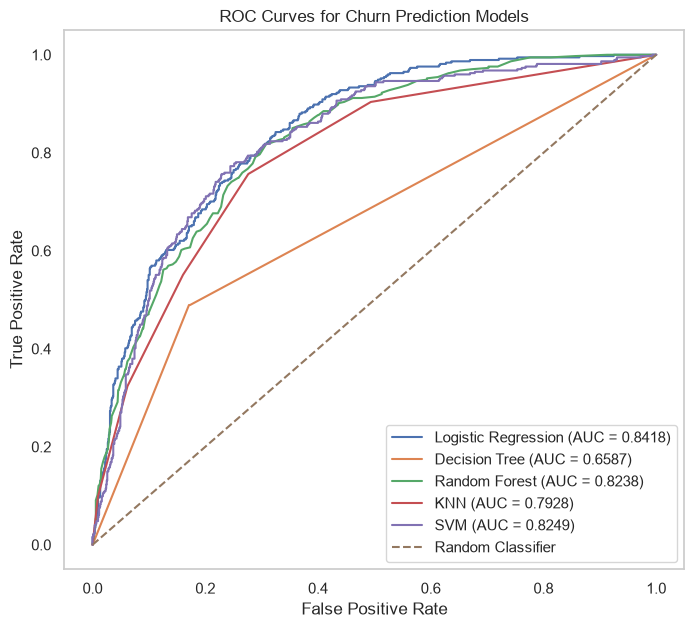

In [72]:
# 14.3 ROC Curve & AUC

from sklearn.metrics import roc_curve, roc_auc_score

# Store models
models = {
    'Logistic Regression': logistic_model,
    'Decision Tree': decision_tree_model,
    'Random Forest': random_forest_model,
    'KNN': knn_model,
    'SVM': svm_model
}

plt.figure(figsize=(8, 7))

# Plot ROC curve for each model
for model_name, model in models.items():
    
    # Get probability scores or decision scores
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_score)
    
    # Calculate AUC
    auc_score = roc_auc_score(y_test, y_score)
    
    plt.plot(
        fpr,
        tpr,
        label=f'{model_name} (AUC = {auc_score:.4f})'
    )

# Random classifier reference line
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Churn Prediction Models')
plt.legend()
plt.grid()
plt.show()

### 14.3.1 Observations

* **Logistic Regression** achieved the highest ROC-AUC of **0.8418**, indicating the strongest overall ability to distinguish between churned and non-churned customers.

* **SVM** achieved a ROC-AUC of **0.8249**, showing strong discriminatory performance and closely following Logistic Regression.

* **Random Forest** achieved a ROC-AUC of **0.8238**, indicating good classification capability, although slightly lower than SVM and Logistic Regression.

* **KNN** achieved a ROC-AUC of **0.7928**, showing moderate ability to distinguish between the two classes.

* **Decision Tree** recorded the lowest ROC-AUC of **0.6587**, indicating comparatively weaker discriminatory performance.

* All five models perform **above the random classifier baseline (AUC = 0.5)**, indicating that each model provides useful predictive information.

* Overall, **Logistic Regression demonstrates the best ROC-AUC performance**, while Decision Tree shows the weakest performance among the evaluated models.


## 14.4 Model Comparison

The performance of the five machine learning models is compared using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

Comparing multiple evaluation metrics provides a more comprehensive assessment of model performance, particularly because the churn dataset contains an imbalanced target variable.

The model with the most suitable balance of performance metrics will be considered for further evaluation and final model selection.


Complete Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7388,0.5052,0.7834,0.6143,0.8418
1,Decision Tree,0.7374,0.5055,0.4893,0.4973,0.6587
2,Random Forest,0.7700,0.5598,0.6257,0.5909,0.8238
3,KNN,0.7630,0.5538,0.5508,0.5523,0.7928
4,SVM,0.7459,0.5141,0.7807,0.6200,0.8249


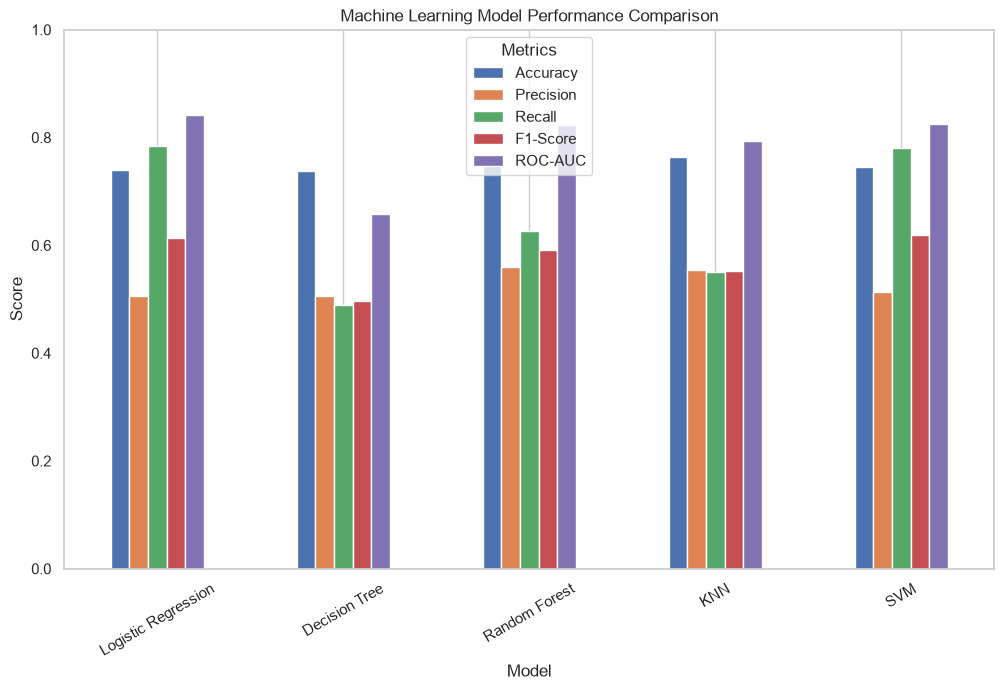

In [73]:
# 14.4 Model Comparison

from sklearn.metrics import roc_auc_score

# Calculate ROC-AUC for each model
auc_scores = []

for model_name, model in models.items():
    
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    
    auc_scores.append(roc_auc_score(y_test, y_score))

# Add ROC-AUC to performance dataframe
performance_df['ROC-AUC'] = auc_scores

# Display complete comparison table
print("Complete Model Performance Comparison:")
display(performance_df.round(4))

# Plot model comparison
performance_df.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
].plot(
    kind='bar',
    figsize=(12, 7)
)

plt.title('Machine Learning Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.legend(title='Metrics')
plt.grid(axis='y')
plt.show()

### 14.4.1 Observations

* **Logistic Regression** achieved the highest **ROC-AUC (0.8418)** and the highest **Recall (0.7834)**, indicating strong overall discrimination and an ability to identify a large proportion of actual churned customers.

* **SVM** achieved the highest **F1-Score (0.6200)** and a very high **Recall (0.7807)**, making it one of the strongest models for identifying churned customers while maintaining a balance between Precision and Recall.

* **Random Forest** achieved the highest **Accuracy (0.7700)** and **Precision (0.5598)**. However, its Recall (0.6257) was lower than Logistic Regression and SVM.

* **KNN** achieved an Accuracy of **0.7630** and showed moderate performance across Precision, Recall, F1-Score, and ROC-AUC.

* **Decision Tree** showed the weakest overall performance, with the lowest **ROC-AUC (0.6587)**, **Recall (0.4893)**, and **F1-Score (0.4973)**.

* Since the dataset contains an imbalanced churn variable, **Accuracy alone is not sufficient for selecting the best model**. Recall, F1-Score, and ROC-AUC are also important for evaluating churn prediction performance.

* Overall, **Logistic Regression and SVM provide the strongest performance for identifying potential churners**, while Random Forest performs best in terms of overall accuracy.


## 14.5 Model Evaluation Summary

The five machine learning models were evaluated using **Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Confusion Matrices** to assess their performance in predicting customer churn.

The evaluation produced the following key findings:

* **Logistic Regression** achieved the highest **ROC-AUC (0.8418)** and a high **Recall (0.7834)**, correctly identifying a large proportion of actual churned customers. Its confusion matrix shows **293 true positives** and **81 false negatives**.

* **SVM** achieved the highest **F1-Score (0.6200)** and a very high **Recall (0.7807)**. Its confusion matrix shows **292 true positives** and only **82 false negatives**, indicating strong performance in identifying churned customers.

* **Random Forest** achieved the highest **Accuracy (0.7700)** and **Precision (0.5598)** among the five models. It correctly identified **234 churned customers**, while producing **140 false negatives**.

* **KNN** achieved an **Accuracy of 0.7630** and moderate performance across the other metrics. Its confusion matrix shows **206 true positives** and **168 false negatives**.

* **Decision Tree** showed the weakest overall performance, with the lowest **ROC-AUC (0.6587)** and **F1-Score (0.4973)**. It also produced **191 false negatives**, indicating weaker identification of churned customers.

* The ROC analysis confirms that all models perform better than the random-classifier baseline, with **Logistic Regression showing the strongest overall discriminatory ability**.

Overall, **Logistic Regression and SVM demonstrated the strongest performance for churn prediction**, particularly in terms of Recall and F1-Score. Random Forest performed best in Accuracy and Precision, while Decision Tree showed the weakest overall results.

Since the primary objective of churn prediction is to identify customers who are likely to leave, **Recall and F1-Score are particularly important alongside ROC-AUC**, rather than relying on Accuracy alone. These results will be considered in the **Final Model Selection** stage.


# Step 15: Final Model Selection

In this step, the best-performing machine learning model will be selected based on the evaluation results obtained in the previous step. The models will be compared using multiple performance metrics, with particular attention given to the model's ability to correctly identify customers who are likely to churn.

### Objectives:
- Compare the performance of all trained models.
- Identify the model with the most suitable overall performance.
- Consider Precision, Recall, F1-Score, Accuracy, and ROC-AUC while making the selection.
- Give appropriate importance to Recall, as correctly identifying potential churners is important for customer retention.
- Select the final model that provides the best balance between predictive performance and practical business requirements.
- Use the selected model for the final customer churn prediction.

## 15.1 Model Selection Criteria

The final model is selected based on its ability to effectively identify customers who are likely to churn.

Since the target variable is imbalanced, **Accuracy alone is not considered sufficient** for final model selection.

The following evaluation metrics are considered:

* **Recall:** Important because it measures how effectively the model identifies actual churned customers.
* **F1-Score:** Provides a balance between Precision and Recall and is useful for evaluating performance on an imbalanced dataset.
* **ROC-AUC:** Measures the model's overall ability to distinguish between churned and non-churned customers.
* **Accuracy:** Considered as a supporting metric to evaluate overall classification performance.

For this customer churn problem, greater importance is given to **Recall, F1-Score, and ROC-AUC**, as correctly identifying customers at risk of churn is a key objective.


In [75]:
# Identify the best-performing model based on evaluation metrics

print("Model Selection Criteria:")
print("- Primary metric: F1-Score")
print("- Supporting metrics: Recall, ROC-AUC, and Accuracy")

# Display models ranked by F1-Score
model_ranking = performance_df.sort_values(
    by='F1-Score',
    ascending=False
).reset_index(drop=True)

print("\nModels Ranked by F1-Score:")
display(model_ranking.round(4))

Model Selection Criteria:
- Primary metric: F1-Score
- Supporting metrics: Recall, ROC-AUC, and Accuracy

Models Ranked by F1-Score:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,SVM,0.7459,0.5141,0.7807,0.6200,0.8249
1,Logistic Regression,0.7388,0.5052,0.7834,0.6143,0.8418
2,Random Forest,0.7700,0.5598,0.6257,0.5909,0.8238
3,KNN,0.7630,0.5538,0.5508,0.5523,0.7928
4,Decision Tree,0.7374,0.5055,0.4893,0.4973,0.6587


## 15.2 Final Model Selection

Based on the evaluation results, **Support Vector Machine (SVM)** is selected as the final model for customer churn prediction.

SVM achieved the highest **F1-Score of 0.6200**, indicating the best balance between Precision and Recall among the evaluated models. It also achieved a high **Recall of 0.7807**, allowing it to correctly identify a large proportion of customers who actually churned.

Although Logistic Regression achieved a slightly higher Recall (**0.7834**) and the highest ROC-AUC (**0.8418**), SVM provided the highest F1-Score, which is particularly relevant for this imbalanced classification problem.

Therefore, considering **F1-Score as the primary criterion**, with Recall, ROC-AUC, and Accuracy as supporting metrics, **SVM is selected as the final model** for predicting customer churn.

The selected SVM model will be further examined in the following sections to summarize its final predictive performance.


In [74]:
# Select the final model based on the evaluation results

final_model = svm_model

# Generate final predictions
y_pred_final = final_model.predict(X_test)

print("Final Model: Support Vector Machine (SVM)")
print("Final model selected successfully.")
print("Test predictions generated successfully.")

Final Model: Support Vector Machine (SVM)
Final model selected successfully.
Test predictions generated successfully.


## 15.3 Final Model Performance

The Support Vector Machine (SVM) was selected as the final model based on its overall performance, particularly its highest F1-Score among the evaluated models.

In this step, the final SVM model is evaluated using **Accuracy, Precision, Recall, F1-Score, and ROC-AUC** on the unseen testing dataset.

These metrics provide a comprehensive assessment of the final model's ability to correctly classify customers as churned or non-churned.


In [76]:
# Evaluate the final SVM model

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Generate predictions
y_pred_final = final_model.predict(X_test)

# Calculate ROC-AUC
if hasattr(final_model, 'predict_proba'):
    y_score_final = final_model.predict_proba(X_test)[:, 1]
else:
    y_score_final = final_model.decision_function(X_test)

final_accuracy = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final)
final_auc = roc_auc_score(y_test, y_score_final)

print("Final Model Performance — SVM")
print("--------------------------------")
print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1-Score : {final_f1:.4f}")
print(f"ROC-AUC  : {final_auc:.4f}")

Final Model Performance — SVM
--------------------------------
Accuracy : 0.7459
Precision: 0.5141
Recall   : 0.7807
F1-Score : 0.6200
ROC-AUC  : 0.8249


### 15.3.1 Observations

* The final **SVM model achieved an Accuracy of 0.7459**, meaning approximately **74.59% of the test customers were classified correctly**.

* The model achieved a **Precision of 0.5141**, indicating that approximately **51.41% of the customers predicted as churners were actually churners**.

* The **Recall of 0.7807** indicates that the model successfully identified approximately **78.07% of the customers who actually churned**.

* The model achieved an **F1-Score of 0.6200**, representing a balance between Precision and Recall.

* The **ROC-AUC of 0.8249** indicates that the model has good ability to distinguish between churned and non-churned customers.

* Overall, the final SVM model demonstrates **strong churn detection capability**, particularly in terms of Recall and F1-Score, making it suitable for identifying customers who may be at risk of leaving the service.


## 15.4 Final Model Summary

The **Support Vector Machine (SVM)** was selected as the final model for customer churn prediction based on its overall performance across the evaluation metrics.

The final model achieved:

* **Accuracy:** 74.59%
* **Precision:** 51.41%
* **Recall:** 78.07%
* **F1-Score:** 62.00%
* **ROC-AUC:** 82.49%

The model demonstrates strong capability in identifying customers who are likely to churn, as indicated by its high Recall and ROC-AUC. Its F1-Score also provides a reasonable balance between Precision and Recall.

Although Logistic Regression achieved a slightly higher Recall and ROC-AUC, SVM achieved the highest F1-Score among the evaluated models. Therefore, SVM is retained as the final model for the customer churn prediction project.

The selected model and its findings will be used in the next stage to develop **business insights and recommendations** for reducing customer churn.


In [77]:
# Final model verification

print("Final Selected Model: Support Vector Machine (SVM)")
print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1-Score : {final_f1:.4f}")
print(f"ROC-AUC  : {final_auc:.4f}")

Final Selected Model: Support Vector Machine (SVM)
Accuracy : 0.7459
Precision: 0.5141
Recall   : 0.7807
F1-Score : 0.6200
ROC-AUC  : 0.8249


# 16. Business Insights & Recommendations

In this step, the results of the customer churn analysis and the final machine learning model will be translated into meaningful business insights. The objective is to understand the major factors associated with customer churn and recommend practical strategies that can help reduce customer loss and improve customer retention.

### Objectives:
- Identify the key factors associated with customer churn.
- Understand the characteristics of customers who are more likely to churn.
- Translate model findings into actionable business insights.
- Recommend suitable customer retention strategies.
- Suggest targeted interventions for high-risk customer segments.
- Explain how predictive churn analysis can support data-driven business decisions.

### Business Recommendations:
- Focus retention efforts on customers identified as having a high probability of churn.
- Pay particular attention to customers with shorter tenure and relatively higher monthly charges.
- Develop suitable retention offers for customers on month-to-month contracts.
- Investigate customer concerns related to internet and technical support services.
- Encourage customers to adopt longer-term contracts through suitable incentives.
- Monitor payment methods and customer segments associated with comparatively higher churn.
- Use the churn prediction model as a decision-support tool for proactive customer retention.

## 16.1 Key Business Insights

The findings from Exploratory Data Analysis (EDA), statistical analysis, and machine learning provide several important business insights into customer churn.

The analysis indicates that customer churn is associated with several customer and service characteristics, including **contract type, internet service, payment method, tenure, and monthly charges**.

Key business insights include:

* Customers with **month-to-month contracts** show substantially higher churn compared with customers on one-year and two-year contracts.

* Customers using **fiber optic internet service** represent an important churn segment and should be monitored closely.

* **Electronic check** users show a comparatively high level of churn, making payment method an important area for further investigation.

* Customers with **shorter tenure** are more likely to churn, indicating that the early stages of the customer relationship are particularly important for retention.

* Customers with **higher monthly charges** show greater churn tendency compared with customers with lower monthly charges.

* Services such as **OnlineSecurity and TechSupport** also show noticeable differences in churn patterns and may provide opportunities for improving customer retention.

* Statistical hypothesis testing confirmed significant relationships between **Churn and Contract Type, Internet Service, and Payment Method**, while significant differences were also found in **Tenure and Monthly Charges** between churned and non-churned customers.

These findings can be used to identify customers at greater risk of churn and develop targeted retention strategies.


In [78]:
# Calculate churn rates for key categorical variables

key_variables = ['Contract', 'InternetService', 'PaymentMethod']

for variable in key_variables:
    churn_rate = (
        df_analysis.groupby(variable)['Churn']
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .sort_values(ascending=False)
    )

    print(f"\nChurn Rate by {variable}:")
    display(churn_rate.round(2))


Churn Rate by Contract:


Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64


Churn Rate by InternetService:


InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn, dtype: float64


Churn Rate by PaymentMethod:


PaymentMethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Churn, dtype: float64

### 16.1.1 Observations

* **Contract Type:** Month-to-month customers have the highest churn rate at **42.71%**, compared with **11.27%** for one-year contracts and only **2.83%** for two-year contracts. This indicates a strong relationship between shorter contract commitment and customer churn.

* **Internet Service:** Customers using **Fiber optic** service have the highest churn rate at **41.89%**, substantially higher than **DSL (18.96%)** and customers with no internet service (**7.40%**).

* **Payment Method:** Customers using **Electronic check** have the highest churn rate at **45.29%**. This is considerably higher than mailed check (**19.11%**), bank transfer (**16.71%**), and credit card (**15.24%**) users.

* These results identify **month-to-month contracts, fiber optic internet service, and electronic check payments** as important high-churn segments.

* The findings suggest that increasing customer commitment, improving the experience of high-churn service segments, and investigating payment-related customer behavior could support churn reduction efforts.

* These insights should be interpreted as **associations rather than causal relationships**, since the analysis does not establish that these characteristics directly cause customers to churn.


## 16.2 High-Risk Customer Segments

The analysis identifies several customer segments that show relatively higher levels of churn.

The major high-risk segments include:

* Customers on **month-to-month contracts**.
* Customers using **fiber optic internet service**.
* Customers paying through **electronic checks**.
* Customers with **shorter tenure**, particularly newer customers.
* Customers with **higher monthly charges**.
* Customers without certain support and security services, such as **OnlineSecurity and TechSupport**, which showed noticeable differences in churn patterns during the EDA.

These segments represent potential areas where targeted customer retention strategies can be applied.

Identifying these groups can help businesses prioritize retention efforts and focus resources on customers who may have a greater likelihood of leaving.


In [79]:
# Analyze churn rates for high-risk customer segments

# Create tenure groups
df_business = df_analysis.copy()

df_business['Tenure_Group'] = pd.cut(
    df_business['tenure'],
    bins=[-1, 12, 24, 48, 72],
    labels=['0–12 months', '13–24 months', '25–48 months', '49–72 months']
)

# Create monthly charge groups using quartiles
df_business['MonthlyCharges_Group'] = pd.qcut(
    df_business['MonthlyCharges'],
    q=4,
    labels=['Low', 'Medium-Low', 'Medium-High', 'High']
)

# Calculate churn rates
tenure_churn_rate = (
    df_business.groupby('Tenure_Group', observed=False)['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
)

monthly_charges_churn_rate = (
    df_business.groupby('MonthlyCharges_Group', observed=False)['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
)

print("Churn Rate by Tenure Group:")
display(tenure_churn_rate.round(2))

print("\nChurn Rate by Monthly Charges Group:")
display(monthly_charges_churn_rate.round(2))

Churn Rate by Tenure Group:


Tenure_Group
0–12 months     47.44
13–24 months    28.71
25–48 months    20.39
49–72 months     9.51
Name: Churn, dtype: float64


Churn Rate by Monthly Charges Group:


MonthlyCharges_Group
Low            11.24
Medium-Low     24.58
Medium-High    37.51
High           32.88
Name: Churn, dtype: float64

### 16.2.1 Observations

* **New customers are the highest-risk tenure group:** Customers with **0–12 months of tenure** have the highest churn rate at **47.44%**.

* Churn decreases consistently as tenure increases:

  * **0–12 months:** 47.44%
  * **13–24 months:** 28.71%
  * **25–48 months:** 20.39%
  * **49–72 months:** 9.51%

* This indicates that the **early customer lifecycle is a critical retention period**, with churn risk substantially higher among newer customers.

* Customers in the **Medium-High monthly charge group** have the highest churn rate at **37.51%**, followed by the **High** group at **32.88%**.

* Customers in the **Low monthly charge group** have the lowest churn rate at **11.24%**, while the Medium-Low group has a churn rate of **24.58%**.

* The results suggest that customers with **shorter tenure and relatively higher monthly charges** should receive greater attention in targeted retention programs.

* These segments should be considered alongside the previously identified high-churn categories, particularly **month-to-month contracts, fiber optic service, and electronic check payments**.

* These findings represent **observed associations in the dataset** and should not be interpreted as proof that tenure or monthly charges directly cause churn.


## 16.3 Churn Reduction Strategies

Based on the identified high-risk customer segments, targeted strategies can be developed to reduce customer churn.

The following strategies are recommended:

* **Strengthen early-stage customer retention:** Since customers with 0–12 months of tenure have the highest churn rate, businesses should introduce onboarding programs, regular follow-ups, and early engagement initiatives.

* **Encourage longer-term contracts:** Since month-to-month customers show substantially higher churn, incentives such as discounts or additional benefits can be offered to encourage customers to move to one-year or two-year contracts.

* **Review fiber optic customer experience:** The high churn rate among fiber optic users suggests that service quality, pricing, installation experience, or customer support for this segment should be investigated.

* **Promote alternative payment methods:** The high churn rate among electronic check users indicates that payment-related behavior should be investigated and customers can be encouraged to use convenient automatic payment options.

* **Provide targeted offers for higher-charge customers:** Customers in higher monthly-charge groups can be offered personalized plans, discounts, or bundled services where appropriate.

* **Improve support and security services:** Customers without services such as OnlineSecurity and TechSupport can be offered relevant service bundles or incentives to increase perceived value and customer satisfaction.

* **Use predictive churn detection:** The final SVM model can be used to identify customers who are more likely to churn so that retention actions can be taken before the customer leaves.


In [80]:
# Create a summary of key churn-risk segments

business_insights = pd.DataFrame({
    'Risk Factor': [
        'Contract Type',
        'Internet Service',
        'Payment Method',
        'Tenure',
        'Monthly Charges'
    ],
    'High-Risk Segment': [
        'Month-to-month',
        'Fiber optic',
        'Electronic check',
        '0–12 months',
        'Medium-High'
    ],
    'Churn Rate (%)': [
        42.71,
        41.89,
        45.29,
        47.44,
        37.51
    ]
})

display(business_insights)

,Risk Factor,High-Risk Segment,Churn Rate (%)
0,Contract Type,Month-to-month,42.71
1,Internet Service,Fiber optic,41.89
2,Payment Method,Electronic check,45.29
3,Tenure,0–12 months,47.44
4,Monthly Charges,Medium-High,37.51


### 16.3.1 Observations

* The **0–12 month tenure segment** has the highest identified churn rate at **47.44%**, making early-stage customer retention the most important area for intervention.

* **Electronic check users** have a churn rate of **45.29%**, suggesting that this customer segment should be investigated and targeted with suitable payment and retention initiatives.

* **Month-to-month customers** have a churn rate of **42.71%**, indicating that encouraging longer-term contracts could be an important retention strategy.

* **Fiber optic customers** have a churn rate of **41.89%**, making this segment another priority for investigating service quality, pricing, and customer support.

* The **Medium-High monthly charge group** has a churn rate of **37.51%**, suggesting that personalized pricing, plan reviews, or value-added offers may be useful for this segment.

* Overall, the results support a **targeted retention approach** rather than applying the same strategy to all customers.

* The final SVM model can complement these business insights by helping identify individual customers who may be at higher risk of churn.


## 16.4 Business Recommendations

Based on the findings from the EDA, statistical analysis, and final SVM model, the following business recommendations are proposed:

1. **Focus on New Customer Retention**
   Introduce stronger onboarding, regular follow-ups, and early-stage engagement programs for customers within their first 12 months.

2. **Encourage Long-Term Contracts**
   Provide discounts, loyalty benefits, or additional services to encourage month-to-month customers to transition to one-year or two-year contracts.

3. **Investigate Fiber Optic Churn**
   Review service quality, pricing, installation experience, technical support, and customer satisfaction among fiber optic customers.

4. **Promote Convenient Payment Options**
   Investigate the high churn rate among electronic check users and encourage suitable automatic payment methods through incentives or simplified payment processes.

5. **Offer Personalized Pricing and Plans**
   Review customers in higher monthly-charge groups and provide personalized plans, bundles, or value-added services where appropriate.

6. **Strengthen Customer Support**
   Promote services such as OnlineSecurity and TechSupport where relevant to improve perceived service value and customer experience.

7. **Use Predictive Retention Campaigns**
   Use the final SVM model to identify customers with a higher predicted likelihood of churn and prioritize them for proactive retention campaigns.

8. **Monitor Retention Performance**
   Track churn rates across customer segments regularly to evaluate whether retention initiatives are reducing customer churn over time.


In [81]:
# Create a business recommendation framework

recommendations = pd.DataFrame({
    'Priority Area': [
        'New Customer Retention',
        'Contract Conversion',
        'Fiber Optic Customers',
        'Payment Methods',
        'Pricing and Plans',
        'Customer Support',
        'Predictive Retention'
    ],
    'Recommended Action': [
        'Strengthen onboarding and early-stage engagement',
        'Encourage longer-term contracts with suitable incentives',
        'Review service quality, pricing, and technical support',
        'Investigate electronic check churn and promote convenient payment options',
        'Provide personalized plans and value-added offers',
        'Promote relevant security and technical support services',
        'Use the SVM model to prioritize high-risk customers'
    ]
})

display(recommendations)

,Priority Area,Recommended Action
0,New Customer Retention,Strengthen onboarding and early-stage engagement
1,Contract Conversion,Encourage longer-term contracts with suitable ...
2,Fiber Optic Customers,"Review service quality, pricing, and technical..."
3,Payment Methods,Investigate electronic check churn and promote...
4,Pricing and Plans,Provide personalized plans and value-added offers
5,Customer Support,Promote relevant security and technical suppor...
6,Predictive Retention,Use the SVM model to prioritize high-risk cust...


### 16.4.1 Observations

* The recommendations focus on the customer segments with the highest observed churn rates, particularly **new customers, month-to-month customers, fiber optic users, and electronic check users**.

* **New customer retention** should receive high priority because the 0–12 month tenure group has the highest churn rate of **47.44%**.

* **Contract conversion initiatives** can target month-to-month customers, who have a churn rate of **42.71%**, by providing suitable incentives for longer-term contracts.

* The **fiber optic segment**, with a churn rate of **41.89%**, should be investigated for potential service quality, pricing, installation, or support issues.

* **Electronic check users** have the highest churn rate among the payment-method categories at **45.29%**, making this an important segment for further investigation and targeted retention efforts.

* Customers with relatively higher monthly charges can be considered for **personalized plans and value-based offers**, particularly because the Medium-High charge group has a churn rate of **37.51%**.

* The final **SVM model** can support these strategies by helping the business identify individual customers who are more likely to churn.

* Overall, the recommendations support a **targeted and data-driven retention strategy** rather than applying identical retention measures to every customer.


## 16.5 Business Insights Summary

The analysis identified several important factors associated with customer churn and translated these findings into actionable business strategies.

The most significant high-churn segments identified were:

* **0–12 month customers:** 47.44% churn rate
* **Electronic check users:** 45.29% churn rate
* **Month-to-month customers:** 42.71% churn rate
* **Fiber optic customers:** 41.89% churn rate
* **Medium-High monthly charge group:** 37.51% churn rate

The findings indicate that customer retention efforts should particularly focus on the **early customer lifecycle, contract type, payment method, internet service, and pricing**.

The business can use targeted onboarding programs, contract incentives, service-quality improvements, convenient payment options, personalized plans, and proactive customer support to address potential churn risks.

The final **SVM model** further supports these efforts by providing a predictive approach for identifying customers who may be at higher risk of churn.

Overall, combining **descriptive analysis, statistical testing, and machine learning predictions** provides a data-driven foundation for developing effective customer retention strategies.


In [82]:
# Final business insights summary

final_business_summary = pd.DataFrame({
    'Key Insight': [
        'New customers have the highest churn risk',
        'Electronic check users have high churn',
        'Month-to-month customers have high churn',
        'Fiber optic customers have high churn',
        'Medium-High monthly charge customers show elevated churn'
    ],
    'Observed Churn Rate (%)': [
        47.44,
        45.29,
        42.71,
        41.89,
        37.51
    ],
    'Recommended Focus': [
        'Strengthen onboarding and early retention',
        'Investigate payment behavior and alternatives',
        'Encourage longer-term contracts',
        'Review service quality and customer support',
        'Offer personalized plans and value-based options'
    ]
})

display(final_business_summary)

,Key Insight,Observed Churn Rate (%),Recommended Focus
0,New customers have the highest churn risk,47.44,Strengthen onboarding and early retention
1,Electronic check users have high churn,45.29,Investigate payment behavior and alternatives
2,Month-to-month customers have high churn,42.71,Encourage longer-term contracts
3,Fiber optic customers have high churn,41.89,Review service quality and customer support
4,Medium-High monthly charge customers show elev...,37.51,Offer personalized plans and value-based options


### 16.5.1 Observations

* The analysis identifies **new customers (0–12 months)** as the highest-risk segment, with a churn rate of **47.44%**.

* **Electronic check users** have the second-highest identified churn rate at **45.29%**, highlighting payment method as an important area for investigation.

* **Month-to-month customers** have a churn rate of **42.71%**, indicating that customers with lower contractual commitment are more likely to churn.

* **Fiber optic customers** have a churn rate of **41.89%**, making this an important segment for service-quality and customer-experience analysis.

* The **Medium-High monthly charge group** has a churn rate of **37.51%**, suggesting an opportunity for personalized pricing and plan optimization.

* These findings provide clear areas for targeted retention efforts and can be combined with the **final SVM model** to identify individual customers who may be at higher risk of churn.

* Overall, the project demonstrates how **EDA, statistical analysis, and machine learning** can work together to transform customer data into actionable business insights.


## 17.1 Project Conclusion

This project focused on predicting customer churn using the Telco Customer Churn dataset and applying a complete data science workflow.

The analysis began with data understanding and preprocessing, followed by Exploratory Data Analysis (EDA), statistical hypothesis testing, feature engineering, data preparation, and machine learning model development.

The EDA identified important patterns in customer tenure, monthly charges, service usage, contract type, and payment methods. Statistical analysis further validated significant relationships between churn and selected categorical and numerical variables.

Five machine learning models were developed and evaluated: **Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors (KNN), and Support Vector Machine (SVM)**.

Among the evaluated models, **SVM was selected as the final model** based primarily on its highest F1-Score, while also demonstrating strong Recall and ROC-AUC performance.

The project demonstrates how data analysis and machine learning can be used to identify customers at risk of churn and support data-driven customer retention strategies.

## 17.2 Key Findings

The major findings from the analysis are:

* **Month-to-month customers** have a high churn rate of **42.71%**.
* **Electronic check users** have a churn rate of **45.29%**.
* **Fiber optic customers** have a churn rate of **41.89%**.
* Customers with **0–12 months of tenure** have the highest observed churn rate at **47.44%**.
* Customers in the **Medium-High monthly charge group** have a churn rate of **37.51%**.
* Contract type, internet service, and payment method showed statistically significant associations with churn.
* Mean tenure and monthly charges were significantly different between churned and non-churned customers.
* **Logistic Regression** achieved the highest ROC-AUC (**0.8418**) and Recall (**0.7834**).
* **SVM** achieved the highest F1-Score (**0.6200**) and was selected as the final model.

## 17.3 Final Model Conclusion

The **Support Vector Machine (SVM)** was selected as the final churn prediction model.

Its final performance on the unseen test dataset was:

* **Accuracy:** 74.59%
* **Precision:** 51.41%
* **Recall:** 78.07%
* **F1-Score:** 62.00%
* **ROC-AUC:** 82.49%

The model's high Recall indicates that it can identify a substantial proportion of customers who actually churned. Its F1-Score provides a reasonable balance between Precision and Recall, while the ROC-AUC indicates good overall discriminatory capability.

Therefore, the SVM model provides a useful predictive foundation for identifying customers who may be at risk of churn and supporting proactive retention activities.

## 17.4 Overall Project Summary

The customer churn prediction project successfully combined **data preprocessing, exploratory analysis, statistical testing, feature engineering, machine learning, model evaluation, and business interpretation** into a complete analytical workflow.

The analysis revealed that churn is particularly concentrated among **newer customers, month-to-month customers, electronic check users, fiber optic customers, and customers with relatively higher monthly charges**.

The machine learning analysis demonstrated that different models perform best under different evaluation criteria. While Logistic Regression achieved the highest ROC-AUC and Recall, SVM achieved the highest F1-Score and was therefore selected as the final model.

The business recommendations focus on strengthening early customer engagement, encouraging longer-term contracts, investigating high-churn service and payment segments, providing personalized plans, improving customer support, and using predictive modeling for proactive retention.

Overall, the project demonstrates the value of combining statistical analysis with machine learning to transform customer data into actionable insights for reducing customer churn.

## 17.5 Final Conclusion Statement

The project successfully developed a data-driven approach for customer churn prediction. The analysis identified key customer segments associated with higher churn and developed an SVM-based predictive model capable of identifying a substantial proportion of potential churners.

The combination of **analytical findings, statistical evidence, predictive modeling, and business recommendations** provides a comprehensive framework that can help a telecom business improve customer retention and make more informed decisions.
